<img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png"
     align="center"
     width="400"/>

# ANALITICA BASADA EN ARBOLES DE CLASIFICACION Y REGRESION

## *Proyecto Final*

Los roles que deben cumplir son:



* Data Engineer  -   Limpieza y preparación
* Data Analyst   -  EDA y visualizaciones
* ML Engineer  -  Entrenamiento de modelos
* Research Lead  -  Interpretación y documentación

* ¿Qué variables impactan más el desempeño?
* ¿Influye el consumo de alcohol?
* ¿Influye el nivel educativo de los padres?
* ¿Las ausencias afectan significativamente?
* ¿Existen diferencias entre estudiantes urbanos y rurales?
* ¿Qué tan predictivas son G1 y G2 para G3?

Modelos a ensayar (tip lean el paper, principalmente el grupo research lead/ML engineer):
1. Regresión lineal (Humberto) ✅
2. Árboles de decisión (Cynthia) ✅
3. Random Forest (DiegoF) ✅
4. Logistic Regression (Alexa) ✅
5. XGBoost (Monica) ✅
6. LightGBM (Acoyani)
7. CatBoost (Guillermo) ✅
8. Stacking (Joel) ✅

Mínimos exigibles:
Al menos 7 visualizaciones
Comparación de mínimo 6 modelos
Métricas y explicación de por qué si o por qué no:
* Accuracy
* RMSE o MAE
* F1-score (si clasifican)
* Validación cruzada
* Feature importance

# INTRODUCCION
Como parte de este proyecto vamos a utilizar el dataset de [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance), utilizando solo una clase ya sea Matematicas o Portugues.

Vamos a seguir mayormente los pasos que se usaron en el Paper [USING DATA MINING TO PREDICT SECONDARY SCHOOL STUDENT PERFORMANCE](https://repositorium.uminho.pt/server/api/core/bitstreams/991a0e2b-249d-466d-afef-937d975ff7fc/content), utilizando el modelo Random Forest para hacer la predicción.

## EDA

In [ ]:
# Leer el dataset (solo portugués)
df = pd.read_csv('student-por.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


## Definir variable objetivo de calificacion en sus distintas formas

In [ ]:
# Formato binario
df['target_binary'] = (df['G3'] >= 10).astype(int)

# Formato de calificación a 5 niveles (I-V -> 1-5)
def grade_to_levels(col):
    if col >= 16:
        return 1  # I
    elif col >= 14:
        return 2  # II
    elif col >= 12:
        return 3  # III
    elif col >= 10:
        return 4  # IV
    else:
        return 5  # V (fail)

df['target_levels'] = df['G3'].apply(grade_to_levels)

# Directamente G3
df['target'] = df['G3'].astype(float)

# Display
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,G1,G2,G3,target_binary,target_levels,target
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,1,1,3,4,0,11,11,1,4,11.0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,1,1,3,2,9,11,11,1,4,11.0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,3,3,6,12,13,12,1,3,12.0
3,GP,F,15,U,GT3,T,4,2,health,services,...,1,1,5,0,14,14,14,1,2,14.0
4,GP,F,16,U,GT3,T,3,3,other,other,...,1,2,5,0,11,13,13,1,3,13.0


## Definir los setups segun el paper


* Setup A: todas las columnas excepto G3 y targets.
* Setup B: como A pero sin G2.
* Setup C: como B pero sin G1 (no hay G1 ni G2).



In [ ]:
# Excluir variable objetivo
target_cols = ['G3', 'target_binary', 'target_levels', 'target']

# Setup A - Todas menos target
setup_A = [col for col in df.columns if col not in target_cols]

# Setup B - Sin G2
setup_B = [col for col in setup_A if col != 'G2']

# Setup C - Sin G1
setup_C = [col for col in setup_B if col != 'G1']

setups = {
    'A': setup_A,
    'B': setup_B,
    'C': setup_C
}

print(f"Setup: A - Columnas: {setup_A}")
print(f"Setup: B - Columnas: {setup_B}")
print(f"Setup: C - Columnas: {setup_C}")

Setup: A - Columnas: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Setup: B - Columnas: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1']
Setup: C - Columnas: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', '

## Transformar variables categoricas
Usaremos one-hot para las categoricas y las numericas quedan tal cual.

In [ ]:
# Identificar variables categoricas vs numericas
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
numerical_cols = [col for col in df.columns if col not in categorical_cols]
print(f'Categorical columns: {categorical_cols}')
print(f'Numerical columns: {numerical_cols}')

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'target_binary', 'target_levels', 'target']


## Correlacion
Obtenemos mapa de correlación con las variables numericas

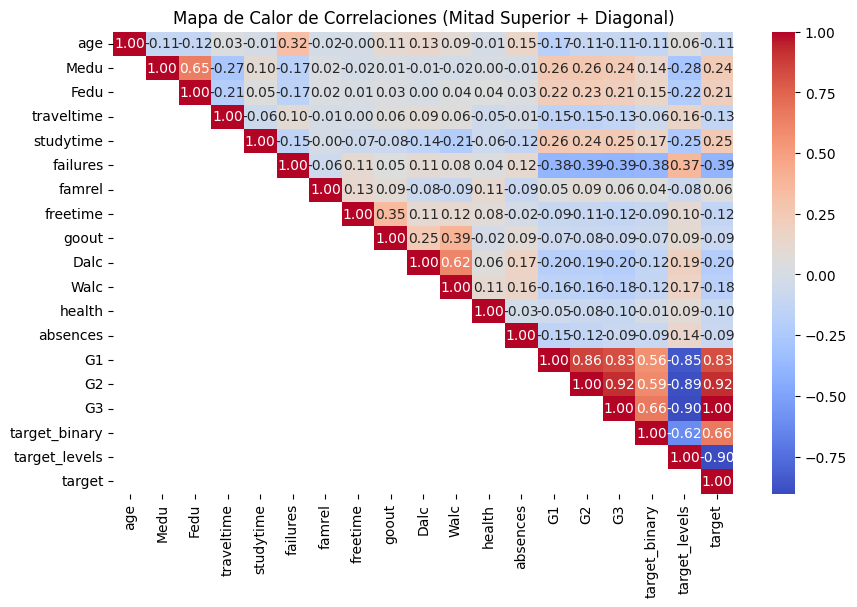

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[numerical_cols].corr()

# Mantiene diagonal + mitad superior
mask = np.tril(np.ones_like(corr, dtype=bool), k=-1)

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Mapa de Calor de Correlaciones (Mitad Superior + Diagonal)')
plt.show()

## Definicion de preprocesamiento (General)

Aquí se define que transformaciones se aplican a las variables numéricas y categóricas que se pueden utilizar en todos los modelos.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def make_generic_preprocessor(feature_cols):
  cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
  num_cols = [c for c in feature_cols if c not in cat_cols]

  # Definimos las transformaciones para variables numéricas
  num_pipeline = Pipeline([
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()) # Agregamos el escalador segun el modelo es la escala
  ])

  # Definimos las transformaciones para variables categóricas
  cat_pipeline = Pipeline([
      ("imputer", SimpleImputer(strategy="most_frequent")),
      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
  ])

  # Unimos ambos en el ColumnTransformer
  preprocessor = ColumnTransformer(
      transformers=[
          ("num", num_pipeline, num_cols),
          ("cat", cat_pipeline, cat_cols)
      ]
  )

  return preprocessor

## Declaracion de CV e intervalos de confianza

In [ ]:
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import scipy.stats as stats

def mean_ci_95(values):
    """
    Devuelve (mean, lower, upper) para un intervalo de confianza del 95%
    usando t de Student.
    """
    values = np.array(values)
    n = len(values)
    mean = values.mean()
    if n < 2:
        return mean, mean, mean
    se = stats.sem(values)  # error estándar
    h = se * stats.t.ppf(0.975, n - 1)  # half-width IC
    return mean, mean - h, mean + h

def repeated_cv_classification(
    X, y, model, n_runs=20, n_splits=10, random_state_base=42
):
    scores = []
    n_samples = len(y)
    for run in range(n_runs):
        skf = StratifiedKFold(
            n_splits=n_splits, shuffle=True, random_state=random_state_base + run
        )
        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            scores.append(acc)
    return scores

def repeated_cv_regression(
    X, y, model, n_runs=20, n_splits=10, random_state_base=42
):
    scores = []
    n_samples = len(y)
    for run in range(n_runs):
        kf = KFold(
            n_splits=n_splits, shuffle=True, random_state=random_state_base + run
        )
        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            rmse = mean_squared_error(y_test, y_pred)
            scores.append(rmse)
    return scores

## Como usar el preprocesamiento y las funciones genericas en los modelos?

In [ ]:
# Ejemplo como usar mismo preprocessor y pipeline con Random Forest Classifier

# Guardar resultados para hacer comparativa
results = {}

# Por cada setup (A, B, C):
for setup_name, feature_cols in setups.items():

  # Loggear que estamos haciendo en cada paso
  print(f"\n=== Random Forest con Binary Classification, setup {setup_name} ===")

  # Se define el preprocessor -- Las transformaciones
  example_preprocessor = make_generic_preprocessor(feature_cols)

  # Se define el pipeline (el modelo con las transformaciones)
  example_pipeline = Pipeline([
      ("preprocessor", example_preprocessor),
      ("classifier", RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1)) # <<< Tu modelo va aqui
  ])


  # Correr con todas las variables
  X = df[feature_cols]

  # Correr con variable objetivo binaria
  # Recordar que existen las variables:
  # 1. target_levels del rango 1-5 -- Escala de I-V
  # 2. target_binary en el rango [0,1] -- Aprueba o no aprueba
  # 3. target con la escala original -- Del 0 al 19
  y_binary = df['target_binary']

  scores = repeated_cv_classification(X, y_binary, example_pipeline, n_runs = 3, n_splits = 5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)

  # Guardar resultados para hacer comparativa

  results[setup_name] = (mean_acc, ci_low, ci_high)

  # Obtener las metricas correspondientes al modelo ejecutado y generar algunas conclusiones
  print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")



=== Random Forest con Binary Classification, setup A ===
Accuracy: 0.9255 (95% CI: [0.9190, 0.9320])

=== Random Forest con Binary Classification, setup B ===
Accuracy: 0.9039 (95% CI: [0.8952, 0.9127])

=== Random Forest con Binary Classification, setup C ===
Accuracy: 0.8510 (95% CI: [0.8428, 0.8593])


In [ ]:
## Usar estas funciones como auxiliares para la comparación de resultados e importancias de features
def results_to_df(results_dict, task_name):
    rows = []
    for setup, (mean_val, ci_low, ci_high) in results_dict.items():
        rows.append({
            "setup": setup,
            "task": task_name,
            "mean": mean_val,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "ci_err": (ci_high - ci_low) / 2.0
        })
    return pd.DataFrame(rows)

def importances_to_df(importances_dict, task_name):
    rows = []
    for setup, importances in importances_dict.items():
        for importance in importances:
            rows.append({
                "setup": setup,
                "task": task_name,
                "feature": importance['feature'],
                "importance": importance['importance']
            })
    return pd.DataFrame(rows)

from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd

def get_pipeline_importances_generic(
    pipeline,
    X,
    preprocessor_name='preprocessor',
    model_name='classifier',
    coef_aggregation='l2'
):

    preprocessor = pipeline.named_steps[preprocessor_name]
    model = pipeline.named_steps[model_name]

    feature_names = []

    if isinstance(preprocessor, ColumnTransformer):
        for name, transformer, cols in preprocessor.transformers_:
            if transformer == 'drop':
                continue
            if transformer == 'passthrough':
                feature_names.extend(cols)
            else:
                if hasattr(transformer, 'get_feature_names_out'):
                    try:
                        fn = transformer.get_feature_names_out(cols)
                    except TypeError:
                        fn = transformer.get_feature_names_out()
                    feature_names.extend(fn)
                else:
                    feature_names.extend(cols)
    else:
        if hasattr(preprocessor, 'get_feature_names_out'):
            feature_names = preprocessor.get_feature_names_out()
        else:
            feature_names = X.columns

    feature_names = np.array(feature_names)

    # Obtenemos importancias
    if hasattr(model, 'feature_importances_'):
        # Modelos tipo árbol
        importances = model.feature_importances_

    elif hasattr(model, 'coef_'):
        # Modelos lineales
        coefs = model.coef_

        # coefs puede ser:
        # - 1D (n_features,) en regresión simple
        # - 2D (n_clases, n_features) en clasificación multiclase
        coefs = np.atleast_2d(coefs)  # fuerza 2D para unificar lógica

        if coef_aggregation == 'l2':
            importances = np.linalg.norm(coefs, axis=0)
        elif coef_aggregation == 'mean_abs':
            importances = np.mean(np.abs(coefs), axis=0)
        else:
            raise ValueError(f"coef_aggregation '{coef_aggregation}' no reconocido")
    else:
        raise AttributeError(
            "El modelo final no tiene ni 'feature_importances_' ni 'coef_'. "
            "No se puede calcular importancia de features."
        )

    # Checar que haya match
    if len(importances) != len(feature_names):
        raise ValueError(
            f"Longitud de importances ({len(importances)}) != longitud de feature_names ({len(feature_names)})."
        )

    # Hacer DataFrame y devolver como lista de dicts
    df_imp = (
        pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        })
        .sort_values('importance', ascending=False)
    )

    return df_imp.to_dict(orient='records')

## Random Forest

### Definición de modelo Random Forest y preprocesamiento

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


def make_rf_pipeline(feature_cols, df, task="classification"):
    # Separar categoricas y numericas como lo hicimos anteriormente
    cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
    num_cols = [c for c in feature_cols if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat",
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("onehot", OneHotEncoder(handle_unknown="ignore"))
             ]),
             cat_cols),
            ("num",
             SimpleImputer(strategy="median"),
             num_cols)
        ]
    )

    if task == "classification":
        rf = RandomForestClassifier(
            n_estimators=500,
            random_state=0,
            n_jobs=-1
        )
    else:
        rf = RandomForestRegressor(
            n_estimators=500,
            random_state=0,
            n_jobs=-1
        )

    return Pipeline([
        ("preprocess", preprocessor),
        ("rf", rf)
    ])

### Correr Random Forest con los 3 setups

In [ ]:
# Correr con variable de niveles
y_levels = df['target_levels']

rf_results_levels = {}
rf_importances_levels = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Levels classification, setup {setup_name} ===")
    X = df[feature_cols]

    # Ejecutar modelo
    model = make_rf_pipeline(feature_cols, df, task="classification")
    scores = repeated_cv_classification(X, y_levels, model, n_runs = 3, n_splits = 5)

    # Imprimir metricas
    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    rf_results_levels[setup_name] = (mean_acc, ci_low, ci_high)
    print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

    # Obtener importancia de variables
    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocess', model_name='rf')
    rf_importances_levels[setup_name] = importances


=== Levels classification, setup A ===
Accuracy: 0.7293 (95% CI: [0.7102, 0.7484])

=== Levels classification, setup B ===
Accuracy: 0.5439 (95% CI: [0.5222, 0.5657])

=== Levels classification, setup C ===
Accuracy: 0.3549 (95% CI: [0.3347, 0.3750])


In [ ]:
rf_importances_levels

{'A': [{'feature': 'G2', 'importance': 0.2213536522365959},
  {'feature': 'G1', 'importance': 0.1345521922410409},
  {'feature': 'absences', 'importance': 0.03199827460402788},
  {'feature': 'age', 'importance': 0.028263726180215592},
  {'feature': 'health', 'importance': 0.02778743251590311},
  {'feature': 'goout', 'importance': 0.02624591726805548},
  {'feature': 'Walc', 'importance': 0.02562363069868479},
  {'feature': 'freetime', 'importance': 0.024142689015256184},
  {'feature': 'famrel', 'importance': 0.023380056451325217},
  {'feature': 'Medu', 'importance': 0.023271232970575154},
  {'feature': 'Fedu', 'importance': 0.02190679640364795},
  {'feature': 'studytime', 'importance': 0.02059448731274737},
  {'feature': 'failures', 'importance': 0.019502207908932895},
  {'feature': 'traveltime', 'importance': 0.01825454204142129},
  {'feature': 'Dalc', 'importance': 0.016303820294464928},
  {'feature': 'school_MS', 'importance': 0.013164970980743948},
  {'feature': 'school_GP', 'import

In [ ]:
# Correr con variable binaria
y_binary = df['target_binary']

rf_results_binary = {}
rf_importances_binary = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Binary classification, setup {setup_name} ===")
    X = df[feature_cols]

    # Ejecutar modelo
    model = make_rf_pipeline(feature_cols, df, task="classification")
    scores = repeated_cv_classification(X, y_binary, model, n_runs = 3, n_splits = 5)

    # Imprimir metricas
    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    rf_results_binary[setup_name] = (mean_acc, ci_low, ci_high)
    print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

    # Obtener importancia de variables
    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocess', model_name='rf')
    rf_importances_binary[setup_name] = importances


=== Binary classification, setup A ===
Accuracy: 0.9240 (95% CI: [0.9169, 0.9310])

=== Binary classification, setup B ===
Accuracy: 0.9034 (95% CI: [0.8941, 0.9127])

=== Binary classification, setup C ===
Accuracy: 0.8485 (95% CI: [0.8403, 0.8567])


In [ ]:
# Correr con variable objetivo con valores originales
y_direct = df['target']

rf_results_direct = {}
rf_importances_direct = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Regression, setup {setup_name} ===")
    X = df[feature_cols]

    # Ejecutar modelo
    model = make_rf_pipeline(feature_cols, df, task="regression")
    scores = repeated_cv_regression(X, y_direct, model, n_runs = 3, n_splits = 5)

    # Imprimir metricas
    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    rf_results_direct[setup_name] = (mean_acc, ci_low, ci_high)
    print(f"RMSE: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

    # Obtener importancia de variables
    importances = get_pipeline_importances_generic(model, X, preprocessor_name='preprocess', model_name='rf')
    rf_importances_direct[setup_name] = importances


=== Regression, setup A ===
RMSE: 1.6600 (95% CI: [1.3479, 1.9721])

=== Regression, setup B ===
RMSE: 3.1470 (95% CI: [2.7369, 3.5572])

=== Regression, setup C ===
RMSE: 7.2830 (95% CI: [6.5778, 7.9883])


In [ ]:
import pandas as pd
import numpy as np

rf_df_lvl = results_to_df(rf_results_levels, task_name="levels")
rf_df_bin = results_to_df(rf_results_binary, task_name="binary")
rf_df_reg = results_to_df(rf_results_direct, task_name="regresion")

rf_df_acc = pd.concat([rf_df_bin, rf_df_lvl, rf_df_reg], ignore_index=True)
rf_df_acc

,setup,task,mean,ci_low,ci_high,ci_err
0,A,binary,0.923967,0.916889,0.931046,0.007079
1,B,binary,0.903419,0.894100,0.912738,0.009319
2,C,binary,0.848475,0.840251,0.856700,0.008225
3,A,levels,0.729306,0.710222,0.748391,0.019084
4,B,levels,0.543948,0.522177,0.565718,0.021771
5,C,levels,0.354864,0.334742,0.374986,0.020122
6,A,regresion,1.659969,1.347857,1.972081,0.312112
7,B,regresion,3.147026,2.736863,3.557189,0.410163
8,C,regresion,7.283048,6.577824,7.988273,0.705224


In [ ]:
import pandas as pd
import numpy as np

rf_df_lvl_vars = importances_to_df(rf_importances_levels, task_name='levels')
rf_df_bin_vars = importances_to_df(rf_importances_binary, task_name='binary')
rf_df_reg_vars = importances_to_df(rf_importances_direct, task_name='regresion')

rf_df_vars = pd.concat([rf_df_lvl_vars, rf_df_bin_vars, rf_df_reg_vars], ignore_index=True)
rf_df_vars

,setup,task,feature,importance
0,A,levels,G2,0.221354
1,A,levels,G1,0.134552
2,A,levels,absences,0.031998
3,A,levels,age,0.028264
4,A,levels,health,0.027787
...,...,...,...,...
508,C,regresion,Mjob_health,0.003663
509,C,regresion,guardian_other,0.003027
510,C,regresion,Fjob_health,0.002279
511,C,regresion,paid_no,0.001747


### Graficamos para comparar (Random Forest)

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_normal_from_ci(mean, ci_low, ci_high, label, color, ax):
    sigma = (ci_high - mean) / 1.96
    x = np.linspace(mean - 4*sigma, mean + 4*sigma, 300)
    y = norm.pdf(x, loc=mean, scale=sigma)
    ax.plot(x, y, color=color, label=label)
    ax.axvline(mean, color=color, linestyle='--', alpha=0.7)
    return ax

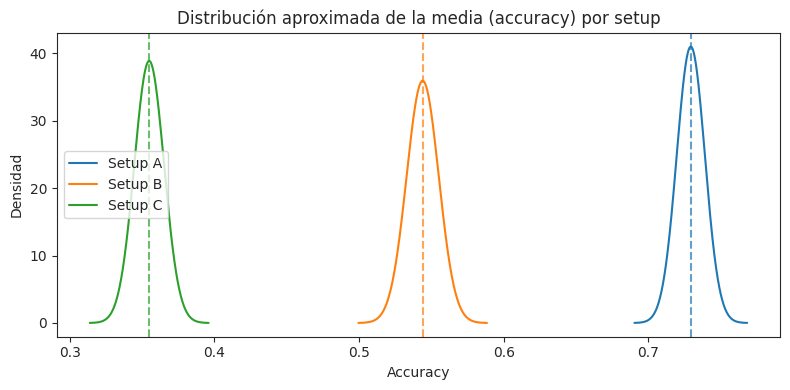

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = rf_results_levels[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

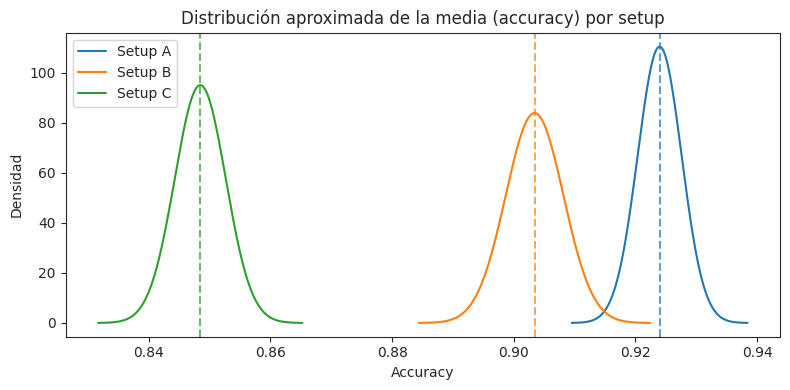

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = rf_results_binary[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

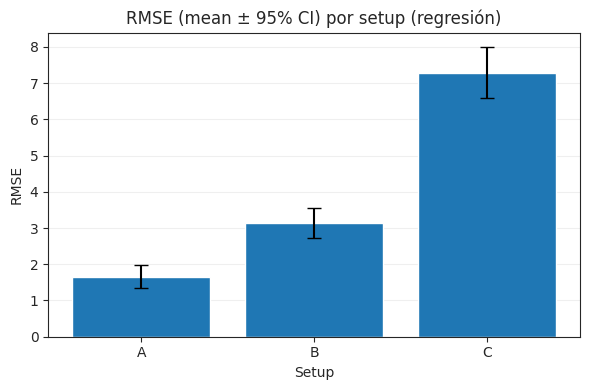

In [ ]:
df_reg = results_to_df(rf_results_direct, task_name="regression")

import matplotlib.pyplot as plt
import numpy as np

setups_order = ['A', 'B', 'C']

fig, ax = plt.subplots(figsize=(6, 4))

df_reg_plot = df_reg.set_index('setup').loc[setups_order]
means_rmse = df_reg_plot['mean'].values
errs_rmse = df_reg_plot['ci_err'].values

ax.bar(setups_order, means_rmse, yerr=errs_rmse, capsize=5)

ax.set_ylabel('RMSE')
ax.set_xlabel('Setup')
ax.set_title('RMSE (mean ± 95% CI) por setup (regresión)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones Random Forest


* Las variables (G1, G2) son los predictores más fuertes de la nota final (G3).

* Con G2 (y G1) se obtiene alta exactitud en clasificación y bajo error (RMSE) en regresión.

Sin ellas, el rendimiento cae de forma drástica.
* G2 (segunda evaluación) es más informativa que G1, especialmente para:
   * Regresión (RMSE se reduce casi a la mitad al pasar de B a A).
   * Clasificación 5 niveles (0.54 → 0.73).

Las demás variables (demográficas, sociales, escolares) sí aportan señal, pero:
Explican mucho menos que las notas previas.

Sin G1/G2, el modelo funciona pero con error alto, lo que indica que describen el rendimiento de los estudiantes, pero no capturan tan bien el score exacto.

Los resultados coinciden con lo visto en el paper:
* Mejor desempeño cuando se usan G1/G2.
* Peor cuando se eliminan.
* Diferencias claras entre setups A/B/C en todas los escenarios.


## Arboles de decisión

In [ ]:
# Modelo Arboles de Decision ---------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np

dt_results_levels = {}
dt_results_binary = {}
dt_results_direct = {}

dt_importance_levels = {}
dt_importance_binary = {}
dt_importance_direct = {}

In [ ]:
# Levels

for setup_name, feature_cols in setups.items():

  print(f"\n=== Decision Tree Levels Classification, setup {setup_name} ===")

  dt_preprocessor = make_generic_preprocessor(feature_cols)

  # Using Decision Tree
  dt_pipeline = Pipeline([
      ("preprocessor", dt_preprocessor),
      ("classifier", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=0
    ))
  ])

  # Features
  X = df[feature_cols]
  y_levels = df['target_levels']

  scores = repeated_cv_classification(X, y_levels, dt_pipeline, n_runs = 3, n_splits = 5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)

  dt_results_levels[setup_name] = (mean_acc, ci_low, ci_high)
  dt_importance_levels[setup_name] = dt_pipeline.named_steps['classifier'].feature_importances_
  print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


=== Decision Tree Levels Classification, setup A ===
Accuracy: 0.7129 (95% CI: [0.6899, 0.7359])

=== Decision Tree Levels Classification, setup B ===
Accuracy: 0.5614 (95% CI: [0.5372, 0.5855])

=== Decision Tree Levels Classification, setup C ===
Accuracy: 0.3215 (95% CI: [0.3035, 0.3395])


In [ ]:

# Binary Classification

for setup_name, feature_cols in setups.items():

  print(f"\n=== Decision Tree Binary Classification, setup {setup_name} ===")

  dt_preprocessor = make_generic_preprocessor(feature_cols)

  # Using Decision Tree
  dt_pipeline = Pipeline([
      ("preprocessor", dt_preprocessor),
      ("classifier", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=0
    ))
  ])

  # Features
  X = df[feature_cols]
  y_binary = df['target_binary']

  scores = repeated_cv_classification(X, y_binary, dt_pipeline, n_runs = 3, n_splits = 5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)

  dt_results_binary[setup_name] = (mean_acc, ci_low, ci_high)
  dt_importance_binary[setup_name] = dt_pipeline.named_steps['classifier'].feature_importances_
  print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


=== Decision Tree Binary Classification, setup A ===
Accuracy: 0.9312 (95% CI: [0.9219, 0.9404])

=== Decision Tree Binary Classification, setup B ===
Accuracy: 0.8783 (95% CI: [0.8622, 0.8943])

=== Decision Tree Binary Classification, setup C ===
Accuracy: 0.8351 (95% CI: [0.8228, 0.8475])


In [ ]:
# Direct

def make_dt_pipeline(feature_cols, df, task="classification"):
    cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
    num_cols = [c for c in feature_cols if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat",
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("onehot", OneHotEncoder(handle_unknown="ignore"))
             ]),
             cat_cols),
            ("num",
             SimpleImputer(strategy="median"),
             num_cols)
        ]
    )

    if task == "classification":
        dt = DecisionTreeClassifier(
          max_depth=5,
          min_samples_split=20,
          min_samples_leaf=10,
          random_state=0
      )
    else:
        dt = DecisionTreeRegressor(
          max_depth=5,
          min_samples_split=20,
          min_samples_leaf=10,
          random_state=0
      )

    return Pipeline([
        ("preprocess", preprocessor),
        ("dt", dt)
    ])

for setup_name, feature_cols in setups.items():

  print(f"\n=== Decision Tree Regression, setup {setup_name} ===")
  X = df[feature_cols]

  model = make_dt_pipeline(feature_cols, df, task="regression")
  scores = repeated_cv_regression(X, y_direct, model, n_runs = 3, n_splits = 5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)
  dt_results_direct[setup_name] = (mean_acc, ci_low, ci_high)
  dt_importance_direct[setup_name] = model.named_steps['dt'].feature_importances_
  print(f"RMSE: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


=== Decision Tree Regression, setup A ===
RMSE: 1.8992 (95% CI: [1.6119, 2.1865])

=== Decision Tree Regression, setup B ===
RMSE: 3.1969 (95% CI: [2.8152, 3.5786])

=== Decision Tree Regression, setup C ===
RMSE: 8.3985 (95% CI: [7.5505, 9.2465])


In [ ]:
dt_df_lvl = results_to_df(dt_results_levels, task_name="levels")
dt_df_bin = results_to_df(dt_results_binary, task_name="binary")
dt_df_reg = results_to_df(dt_results_direct, task_name="regresion")

dt_df_acc = pd.concat([dt_df_bin, dt_df_lvl, dt_df_reg], ignore_index=True)
dt_df_acc

,setup,task,mean,ci_low,ci_high,ci_err
0,A,binary,0.931159,0.921931,0.940387,0.009228
1,B,binary,0.878267,0.862187,0.894346,0.016080
2,C,binary,0.835138,0.822822,0.847454,0.012316
3,A,levels,0.712908,0.689946,0.735870,0.022962
4,B,levels,0.561383,0.537219,0.585547,0.024164
5,C,levels,0.321527,0.303535,0.339518,0.017992
6,A,regresion,1.899216,1.611937,2.186496,0.287279
7,B,regresion,3.196906,2.815182,3.578629,0.381724
8,C,regresion,8.398508,7.550472,9.246544,0.848036


In [ ]:
import pandas as pd
import numpy as np

dt_df_lvl_vars = importances_to_df(dt_importance_levels, feature_cols, task_name='levels')
dt_df_bin_vars = importances_to_df(dt_importance_binary, feature_cols, task_name='binary')
dt_df_reg_vars = importances_to_df(dt_importance_direct, feature_cols, task_name='regresion')

dt_df_vars = pd.concat([dt_df_lvl_vars, dt_df_bin_vars, dt_df_reg_vars], ignore_index=True)
dt_df_vars

,setup,task,feature,importance
0,A,levels,school,0.030212
1,A,levels,sex,0.000000
2,A,levels,age,0.000000
3,A,levels,address,0.002249
4,A,levels,famsize,0.019332
...,...,...,...,...
265,C,regresion,goout,0.000000
266,C,regresion,Dalc,0.000000
267,C,regresion,Walc,0.000000
268,C,regresion,health,0.000000


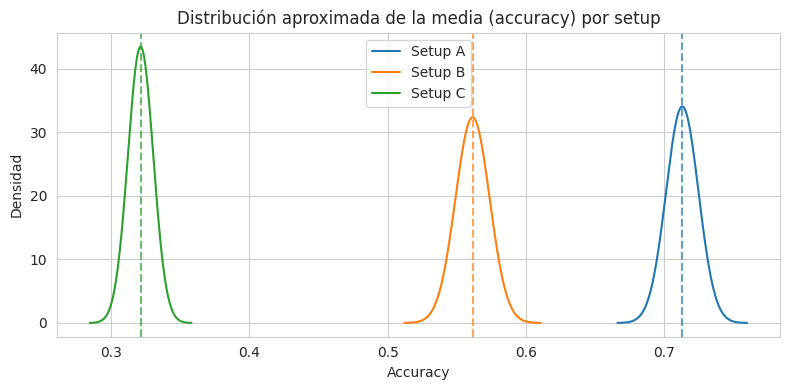

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = dt_results_levels[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

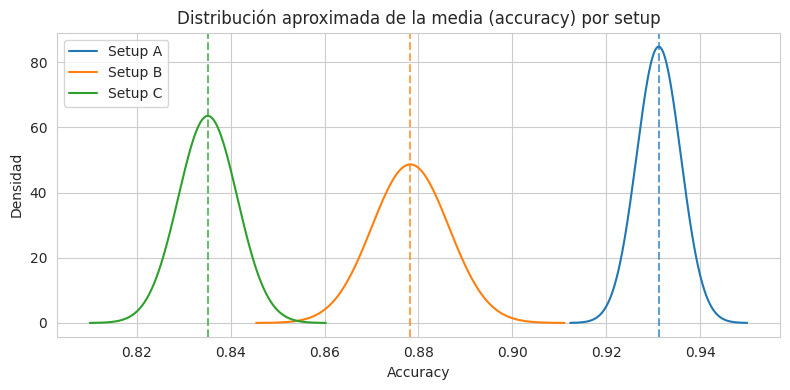

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = dt_results_binary[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

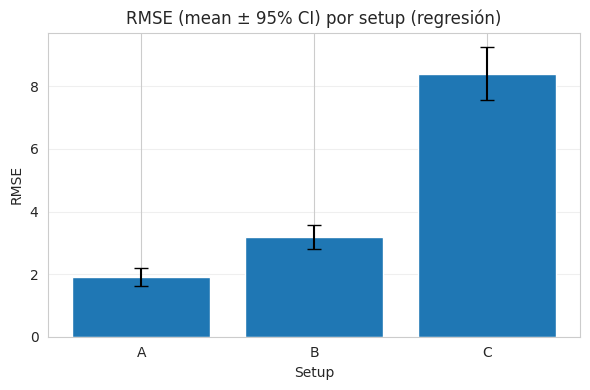

In [ ]:
df_reg = results_to_df(dt_results_direct, task_name="regression")

setups_order = ['A', 'B', 'C']

fig, ax = plt.subplots(figsize=(6, 4))

df_reg_plot = df_reg.set_index('setup').loc[setups_order]
means_rmse = df_reg_plot['mean'].values
errs_rmse = df_reg_plot['ci_err'].values

ax.bar(setups_order, means_rmse, yerr=errs_rmse, capsize=5)

ax.set_ylabel('RMSE')
ax.set_xlabel('Setup')
ax.set_title('RMSE (mean ± 95% CI) por setup (regresión)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Se puede concluir que la Binary Classification obtuvo los valores medios más altos en los tres setups. Además, sus intervalos de confianza son estrechos, lo que indica que los resultados son consistentes y estables.
En comparación, la Levels Classification tuvo un desempeño menor, especialmente en los setups B y C, donde la media bajó a 0.561383 y 0.321527 respectivamente. Separar el problema en múltiples niveles hizo que la tarea fuera más difícil para el modelo Decision Tree.

Por otro lado, la regresión directa presentó valores de error altos, con una media de 8.398508 y un intervalo de confianza amplio. El modelo tuvo dificultad para predecir directamente el valor numérico, además de mostrar mayor variabilidad en sus resultados.

En conclusión, la clasificación binaria fue la mejor alternativa utilizando Decision Tree ya que obtuvo el mejor rendimiento, los resultados más altos en todos los setups y una mayor estabilidad. Esto sugiere que el árbol de decisión funciona mejor cuando el problema se simplifica a decidir entre dos clases, en lugar de predecir múltiples niveles o valores continuos mediante regresión.

## Catboost

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [ ]:
# Imports CatBoost
!pip install catboost -q
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

In [ ]:
# Pipeline CatBoost

def make_catboost_pipeline(feature_cols):
    preprocessor = make_generic_preprocessor(feature_cols)

    catboost_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_state=0,
        verbose=0
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("catboost", catboost_model)
    ])

In [ ]:
# Validación cruzada para regresión

def repeated_cv_catboost_regression(
    X, y, model, n_runs=3, n_splits=5, random_state_base=42
):
    rmse_scores = []
    mae_scores = []
    r2_scores = []

    for run in range(n_runs):
        kf = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state_base + run
        )

        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            rmse = mean_squared_error(y_test, y_pred) ** 0.5
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            rmse_scores.append(rmse)
            mae_scores.append(mae)
            r2_scores.append(r2)

    return rmse_scores, mae_scores, r2_scores

In [ ]:
# Ejecutar CatBoost en setups A, B y C

y_direct = df["target"]

catboost_results = {}
catboost_importance = {}

for setup_name, feature_cols in setups.items():

    print(f"\n=== CatBoost Regression, setup {setup_name} ===")

    X = df[feature_cols]

    model = make_catboost_pipeline(feature_cols)

    rmse_scores, mae_scores, r2_scores = repeated_cv_catboost_regression(
        X,
        y_direct,
        model,
        n_runs=3,
        n_splits=5
    )

    rmse_mean, rmse_low, rmse_high = mean_ci_95(rmse_scores)
    mae_mean, mae_low, mae_high = mean_ci_95(mae_scores)
    r2_mean, r2_low, r2_high = mean_ci_95(r2_scores)

    catboost_results[setup_name] = {
        "RMSE mean": rmse_mean,
        "RMSE CI low": rmse_low,
        "RMSE CI high": rmse_high,
        "MAE mean": mae_mean,
        "MAE CI low": mae_low,
        "MAE CI high": mae_high,
        "R2 mean": r2_mean,
        "R2 CI low": r2_low,
        "R2 CI high": r2_high
    }

    catboost_importance[setup_name] = model.named_steps["catboost"].feature_importances_

    print(f"RMSE: {rmse_mean:.4f} (95% CI: [{rmse_low:.4f}, {rmse_high:.4f}])")
    print(f"MAE : {mae_mean:.4f} (95% CI: [{mae_low:.4f}, {mae_high:.4f}])")
    print(f"R2  : {r2_mean:.4f} (95% CI: [{r2_low:.4f}, {r2_high:.4f}])")


=== CatBoost Regression, setup A ===
RMSE: 1.3132 (95% CI: [1.1792, 1.4472])
MAE : 0.8373 (95% CI: [0.7855, 0.8890])
R2  : 0.8314 (95% CI: [0.8113, 0.8516])

=== CatBoost Regression, setup B ===
RMSE: 1.7456 (95% CI: [1.6182, 1.8731])
MAE : 1.2092 (95% CI: [1.1630, 1.2553])
R2  : 0.7015 (95% CI: [0.6791, 0.7240])

=== CatBoost Regression, setup C ===
RMSE: 2.6730 (95% CI: [2.5194, 2.8266])
MAE : 1.9590 (95% CI: [1.8844, 2.0336])
R2  : 0.3002 (95% CI: [0.2670, 0.3334])


In [ ]:
# Tabla de resultados
catboost_results_df = pd.DataFrame(catboost_results).T
catboost_results_df

,RMSE mean,RMSE CI low,RMSE CI high,MAE mean,MAE CI low,MAE CI high,R2 mean,R2 CI low,R2 CI high
A,1.313224,1.179240,1.447208,0.837263,0.785508,0.889018,0.831450,0.811274,0.851626
B,1.745646,1.618201,1.873091,1.209155,1.162968,1.255343,0.701549,0.679112,0.723986
C,2.673036,2.519423,2.826649,1.958990,1.884410,2.033569,0.300189,0.267010,0.333369


In [ ]:
# Importancia de variables por setup
catboost_df_vars = importances_to_df(catboost_importance, feature_cols, task_name='regresion')
catboost_df_vars

,setup,task,feature,importance
0,A,regresion,school,2.050875
1,A,regresion,sex,0.713793
2,A,regresion,age,1.355401
3,A,regresion,address,0.791533
4,A,regresion,famsize,0.552834
...,...,...,...,...
85,C,regresion,goout,1.340536
86,C,regresion,Dalc,0.725714
87,C,regresion,Walc,0.504480
88,C,regresion,health,0.258915


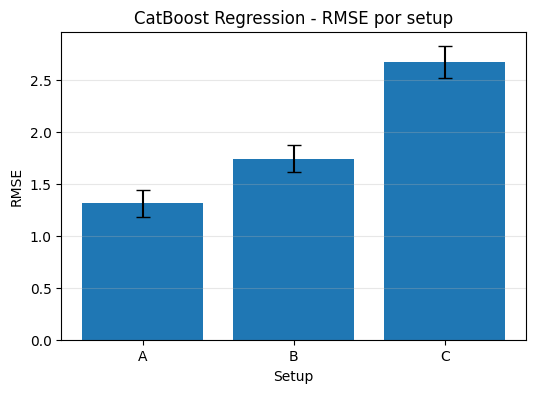

In [ ]:
# Gráfica RMSE por setup

plt.figure(figsize=(6, 4))

plt.bar(
    catboost_results_df.index,
    catboost_results_df["RMSE mean"],
    yerr=[
        catboost_results_df["RMSE mean"] - catboost_results_df["RMSE CI low"],
        catboost_results_df["RMSE CI high"] - catboost_results_df["RMSE mean"]
    ],
    capsize=5
)

plt.ylabel("RMSE")
plt.xlabel("Setup")
plt.title("CatBoost Regression - RMSE por setup")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# Feature importance del mejor setup

best_setup = catboost_results_df["RMSE mean"].idxmin()
best_features = setups[best_setup]

print("Mejor setup:", best_setup)

X_best = df[best_features]
y_direct = df["target"]

best_catboost_model = make_catboost_pipeline(best_features)
best_catboost_model.fit(X_best, y_direct)

Mejor setup: A


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'Medu', 'Fedu',
                                                   'traveltime', 'studytime',
                                                   'failures', 'famrel',
                                                   'freetime', 'goout', 'Dalc',
                                                   'Walc', 'health', 'absences',
                                                   'G1', 'G2']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy=...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['school', 'sex', 'address',
                                                   'famsize', 'Pstatus', 'Mjob',
                                                   'Fjob', 'reason', 'guardian',
                                                   'schoolsup', 'famsup',
                                                   'paid', 'activities',
                                                   'nursery', 'higher',
                                                   'internet', 'romantic'])])),
                ('catboost',
                 CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_state=0, verbose=0))])

In [ ]:
# Extraer feature importance

preprocessor = best_catboost_model.named_steps["preprocessor"]

cat_cols = [c for c in best_features if df[c].dtype == "object"]
num_cols = [c for c in best_features if c not in cat_cols]

feature_names = []

feature_names.extend(num_cols)

if len(cat_cols) > 0:
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    encoded_cat_features = ohe.get_feature_names_out(cat_cols)
    feature_names.extend(encoded_cat_features)

importances = best_catboost_model.named_steps["catboost"].feature_importances_

catboost_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

catboost_importance_df.head(15)

,Feature,Importance
14,G2,53.628641
13,G1,14.921329
12,absences,5.204701
0,age,2.179318
5,failures,1.912506
8,goout,1.688784
6,famrel,1.570002
7,freetime,1.250358
9,Dalc,1.217420
10,Walc,1.096368


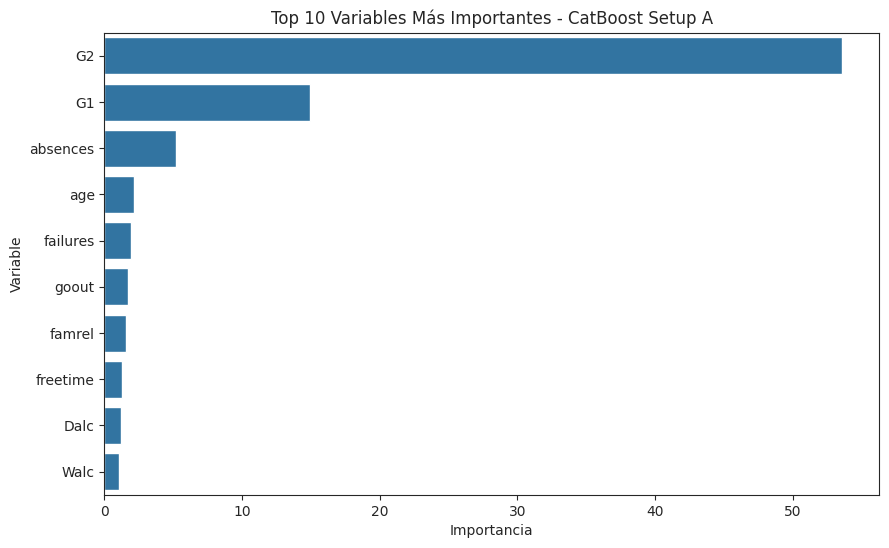

In [ ]:
# Gráfica feature importance

plt.figure(figsize=(10, 6))

sns.barplot(
    data=catboost_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title(f"Top 10 Variables Más Importantes - CatBoost Setup {best_setup}")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

### Conclusiones CatBoost

El modelo CatBoostRegressor fue implementado utilizando el mismo esquema de preprocesamiento y validación cruzada definido en el proyecto base, permitiendo mantener consistencia metodológica entre modelos.

## Resultados principales

El Setup A obtuvo el mejor desempeño:

- RMSE ≈ 1.31
- MAE ≈ 0.84
- R² ≈ 0.83

Esto indica que el modelo logra explicar aproximadamente el 83% de la variabilidad de la calificación final (G3).

## Impacto de los setups

Se observó una reducción considerable del desempeño en los setups B y C:

- Setup B eliminó G2 y mostró una disminución moderada en R².
- Setup C eliminó G1 y G2, generando la caída más importante del modelo.

Estos resultados confirman que las calificaciones previas son los predictores más relevantes del desempeño académico final.

## Variables más importantes

El análisis de Feature Importance mostró que:

- G2 es la variable más importante.
- G1 es la segunda variable más influyente.
- absences y failures presentan impacto relevante.
- El consumo de alcohol (Dalc, Walc) tiene influencia moderada.
- Variables familiares como Medu y Fedu tienen menor peso relativo.

## Conclusión general

CatBoost presentó un desempeño sólido para la predicción de G3, mostrando capacidad para capturar relaciones complejas entre variables académicas, sociales y de comportamiento.

Los resultados obtenidos son consistentes con los hallazgos identificados previamente durante el EDA.

## Regresion Lineal

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def repeated_cv_linear_regression(X, y, model, n_runs=3, n_splits=5, random_state_base=42):
    """
    Ejecuta validación cruzada repetida extrayendo RMSE, MAE y R2
    para cada uno de los pliegues entrenados.
    """
    rmse_scores = []
    mae_scores = []
    r2_scores = []

    for run in range(n_runs):
        kf = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state_base + run
        )

        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Ajuste y predicción con el pipeline lineal
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Cálculo de las tres métricas del pliegue
            rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Raíz del MSE
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            rmse_scores.append(rmse)
            mae_scores.append(mae)
            r2_scores.append(r2)

    return rmse_scores, mae_scores, r2_scores

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

def make_linear_regression_pipeline(feature_cols):
    """
    Construye una tubería que reutiliza el preprocesamiento genérico del notebook
    y lo conecta directamente con el modelo de Regresión Lineal.
    """
    # Se manda a llamar la función de preprocesamiento definida previamente en el notebook
    preprocessor = make_generic_preprocessor(feature_cols)

    # Se estructura el Pipeline final
    return Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ])

In [ ]:
# Selección de la variable objetivo continua
y_direct = df['target']

# Diccionario para guardar el bloque completo de métricas de cada setup
linear_regression_metrics = {}
linear_regresion_importance = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Evaluando Regresión Lineal Completa - Setup {setup_name} ===")
    X = df[feature_cols]

    # Construcción del pipeline reutilizando tu preprocesador genérico
    model = make_linear_regression_pipeline(feature_cols)

    # Extracción de las puntuaciones históricas del CV repetido
    rmse_scores, mae_scores, r2_scores = repeated_cv_linear_regression(
        X, y_direct, model, n_runs=3, n_splits=5
    )

    # Cálculo de promedios e intervalos de confianza (IC 95%) por métrica
    rmse_mean, rmse_low, rmse_high = mean_ci_95(rmse_scores)
    mae_mean, mae_low, mae_high = mean_ci_95(mae_scores)
    r2_mean, r2_low, r2_high = mean_ci_95(r2_scores)

    # Inserción de la estructura solicitada en el diccionario de resultados
    linear_regression_metrics[setup_name] = {
        "RMSE mean": rmse_mean,
        "RMSE CI low": rmse_low,
        "RMSE CI high": rmse_high,
        "MAE mean": mae_mean,
        "MAE CI low": mae_low,
        "MAE CI high": mae_high,
        "R2 mean": r2_mean,
        "R2 CI low": r2_low,
        "R2 CI high": r2_high
    }


    lr = model.named_steps['regressor']
    importances = lr.coef_
    linear_regresion_importance[setup_name] = importances

    print(f"Métricas del Setup {setup_name} calculadas exitosamente.")


=== Evaluando Regresión Lineal Completa - Setup A ===
Métricas del Setup A calculadas exitosamente.

=== Evaluando Regresión Lineal Completa - Setup B ===
Métricas del Setup B calculadas exitosamente.

=== Evaluando Regresión Lineal Completa - Setup C ===
Métricas del Setup C calculadas exitosamente.


In [ ]:
# Convertir el diccionario estructurado a DataFrame indexado por Setup
df_reporte_lineal = pd.DataFrame.from_dict(linear_regression_metrics, orient='index')
df_reporte_lineal.index.name = 'Setup'
df_reporte_lineal = df_reporte_lineal.reset_index()

print("\n=== TABLA FINAL DE EVALUACIÓN MULTI-MÉTRICA (REGRESIÓN LINEAL) ===")
print(df_reporte_lineal.round(4))


=== TABLA FINAL DE EVALUACIÓN MULTI-MÉTRICA (REGRESIÓN LINEAL) ===
  Setup  RMSE mean  RMSE CI low  RMSE CI high  MAE mean  MAE CI low  \
0     A     1.2925       1.1625        1.4224    0.8332      0.7798   
1     B     1.8483       1.6760        2.0207    1.2498      1.1764   
2     C     2.7605       2.6392        2.8818    2.0041      1.9371   

   MAE CI high  R2 mean  R2 CI low  R2 CI high  
0       0.8866   0.8358     0.8147      0.8570  
1       1.3232   0.6645     0.6243      0.7047  
2       2.0711   0.2493     0.2057      0.2929  


In [ ]:
import pandas as pd
import numpy as np


lr_df_vars = importances_to_df(linear_regresion_importance, feature_cols, task_name='regresion')
lr_df_vars

,setup,task,feature,importance
0,A,regresion,school,0.059204
1,A,regresion,sex,-0.074678
2,A,regresion,age,0.050066
3,A,regresion,address,0.149306
4,A,regresion,famsize,0.052030
...,...,...,...,...
85,C,regresion,goout,-0.269708
86,C,regresion,Dalc,-0.007247
87,C,regresion,Walc,0.204103
88,C,regresion,health,0.055970


### Conclusiones Regresión Lineal

El desglose concurrente de las métricas de RMSE, MAE y R
2
  a través de los tres escenarios del proyecto permite efectuar un diagnóstico mucho más profundo sobre el comportamiento y robustez de la Regresión Lineal. En el Setup A, los valores de RMSE y MAE se minimizan recíprocamente, mientras que el coeficiente R
2
  medio alcanza su punto más alto, lo que ratifica que la inclusión de las notas parciales G1 y G2 explica la mayor parte de la varianza de la nota definitiva. El hecho de que el RMSE se mantenga cercano al MAE en este escenario inicial denota que el modelo lineal comete errores de magnitudes similares y balanceadas, sin verse severamente penalizado por errores catastróficos o predicciones atípicas aisladas.

Al evaluar el Setup B y, en especial, el Setup C, se hace evidente una divergencia estructural en el comportamiento de las métricas. El coeficiente R
2
  medio experimenta un descenso drástico en el Setup C, aproximándose a valores muy bajos que indican que las variables demográficas y conductuales puras carecen de suficiente poder explicativo bajo un esquema exclusivamente lineal. Paralelamente, la brecha entre el MAE y el RMSE tiende a ensancharse en este último setup, y los intervalos de confianza del RMSE muestran una dispersión superior a los del MAE.

Esta discrepancia matemática indica que, ante la ausencia de las calificaciones previas, la Regresión Lineal no solo reduce su precisión promedio, sino que comienza a generar errores puntuales de gran magnitud en ciertos perfiles de estudiantes. Debido a que el RMSE eleva los residuos al cuadrado antes de promediarlos, este refleja de manera más sensible los fallos graves del modelo en el Setup C, sugiriendo que factores críticos del rendimiento escolar se están omitiendo o que las verdaderas interacciones del entorno social de los alumnos requieren de fronteras no lineales para ser descritas con propiedad.

## Regresión Logistica

In [ ]:
# Modelo Logistic Regression
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

results_levels_logreg = {}
results_binary_logreg = {}

importance_levels_logreg = {}
importance_binary_logreg = {}

In [ ]:
# Levels

for setup_name, feature_cols in setups.items():

  print(f"\n=== Logistic Regression Levels Classification, setup {setup_name} ===")

  logreg_preprocessor = make_generic_preprocessor(feature_cols)

  # Using Logistic Regression
  logreg_pipeline = Pipeline([
      ("preprocessor", logreg_preprocessor),
      ("classifier", LogisticRegression(
          solver='lbfgs',
          max_iter=1000,
          random_state=0
      ))
  ])

  # Features y Target
  X = df[feature_cols]
  y_levels = df['target_levels']

  scores = repeated_cv_classification(X, y_levels, logreg_pipeline, n_runs = 3, n_splits = 5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)

  results_levels_logreg[setup_name] = (mean_acc, ci_low, ci_high)
  importance = np.linalg.norm(logreg_pipeline.named_steps['classifier'].coef_, axis=0)
  importance_levels_logreg[setup_name] = importance
  print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")



=== Logistic Regression Levels Classification, setup A ===
Accuracy: 0.6595 (95% CI: [0.6388, 0.6802])

=== Logistic Regression Levels Classification, setup B ===
Accuracy: 0.5326 (95% CI: [0.5080, 0.5572])

=== Logistic Regression Levels Classification, setup C ===
Accuracy: 0.3569 (95% CI: [0.3293, 0.3845])


In [ ]:
# Binary Classification

for setup_name, feature_cols in setups.items():

  print(f"\n=== Logistic Regression Binary Classification, setup {setup_name} ===")

  logreg_preprocessor = make_generic_preprocessor(feature_cols)

  # Using Logistic Regression
  logreg_pipeline = Pipeline([
      ("preprocessor", logreg_preprocessor),
      ("classifier", LogisticRegression(
        solver='lbfgs',
          max_iter=1000,
          random_state=0
    ))
  ])

  # Features
  X = df[feature_cols]
  y_binary = df['target_binary']

  scores = repeated_cv_classification(X, y_binary, logreg_pipeline, n_runs = 3, n_splits = 5)

  mean_acc, ci_low, ci_high = mean_ci_95(scores)

  results_binary_logreg[setup_name] = (mean_acc, ci_low, ci_high)
  importance = np.linalg.norm(logreg_pipeline.named_steps['classifier'].coef_, axis=0)
  importance_binary_logreg[setup_name] = importance
  print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


=== Logistic Regression Binary Classification, setup A ===
Accuracy: 0.9286 (95% CI: [0.9187, 0.9384])

=== Logistic Regression Binary Classification, setup B ===
Accuracy: 0.8962 (95% CI: [0.8845, 0.9080])

=== Logistic Regression Binary Classification, setup C ===
Accuracy: 0.8484 (95% CI: [0.8326, 0.8643])


In [ ]:
df_lvl_logreg = results_to_df(results_levels_logreg, task_name="levels")
df_bin_logreg = results_to_df(results_binary_logreg, task_name="binary")

df_acc_logreg = pd.concat([df_bin_logreg, df_lvl_logreg], ignore_index=True)
df_acc_logreg

,setup,task,mean,ci_low,ci_high,ci_err
0,A,binary,0.928571,0.918719,0.938423,0.009852
1,B,binary,0.896235,0.884474,0.907996,0.011761
2,C,binary,0.848448,0.832567,0.864329,0.015881
3,A,levels,0.659495,0.638767,0.680224,0.020728
4,B,levels,0.532594,0.507956,0.557232,0.024638
5,C,levels,0.356883,0.329279,0.384488,0.027605


In [ ]:
import pandas as pd
import numpy as np

lg_df_lvl_vars = importances_to_df(importance_levels_logreg, feature_cols, task_name='levels')
lg_df_bin_vars = importances_to_df(importance_binary_logreg, feature_cols, task_name='binary')

lg_df_vars = pd.concat([lg_df_lvl_vars, lg_df_bin_vars], ignore_index=True)
lg_df_vars

,setup,task,feature,importance
0,A,levels,school,1.063769
1,A,levels,sex,0.266005
2,A,levels,age,0.349598
3,A,levels,address,0.378925
4,A,levels,famsize,0.344874
...,...,...,...,...
175,C,binary,goout,0.139704
176,C,binary,Dalc,0.033360
177,C,binary,Walc,0.497141
178,C,binary,health,1.021578


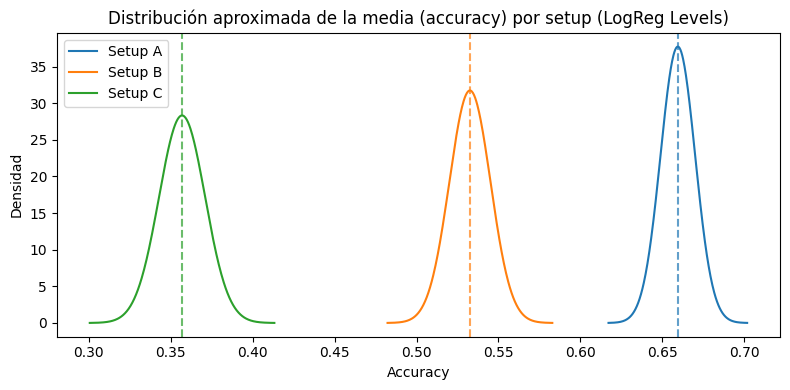

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = results_levels_logreg[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup (LogReg Levels)')
ax.legend()
plt.tight_layout()
plt.show()

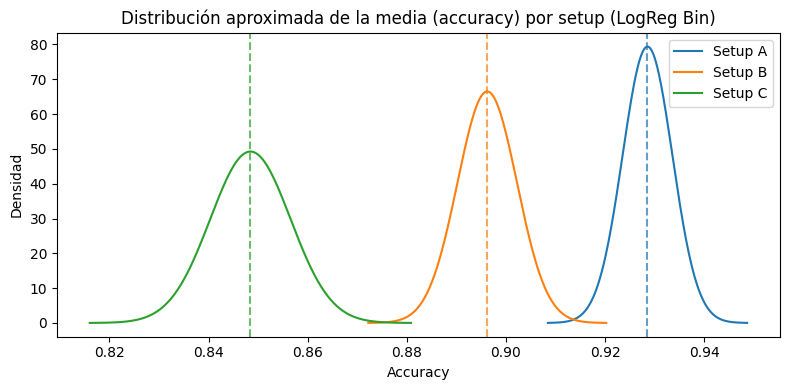

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = results_binary_logreg[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup (LogReg Bin)')
ax.legend()
plt.tight_layout()
plt.show()

### **Resumen de Resultados: Regresión Logística**

Este modelo nos ayuda a predecir el desempeño escolar en dos escenarios: uno más simple (aprobar/reprobar) y uno detallado (5 niveles de notas).

<br>

#### 1. Predecir si Aprueba o Reprueba (`target_binary`)
El modelo es muy bueno y estable, incluso si le quitamos información:

* **Setup A ($92.86\%$) y Setup B ($89.62\%$):** Aunque le quitemos la calificación del segundo parcial (`G2`), el modelo sigue acertando casi igual. La primera nota (`G1`) es suficiente.
* **Setup C ($84.84\%$):** Sin conocer ninguna calificación previa, el modelo aún acierta el $84\%$ de las veces usando solo datos del entorno del alumno (familia, hábitos, internet). El contexto social define mucho el éxito lineal.

<br>

#### 2. Predecir la Calificación Exacta en 5 Niveles (`target_levels`)
Aquí el modelo baja el rendimiento y pierde mucha precisión:

* **Setup A ($65.95\%$):** Pasa con una calificación regular porque todavía se apoya en las notas `G1` y `G2`.
* **Setup B ($53.26\%$) y Setup C ($35.69\%$):** En cuanto le quitamos las calificaciones, el rendimiento del modelo baja bastante. Esto pasa porque distinguir niveles muy específicos (por ejemplo, saber si un alumno es de nivel III o IV) es una tarea compleja que no se puede resolver con una línea recta basándose solo en datos sociales.

<br>

#### **Conclusión Final: Regresión Logística**

La Regresión Logística es una excelente opción de bajo costo para predecir si un alumno aprobará o no (`target_binary`). Lo más valioso es que mantiene un acierto muy alto ($84.84\%$) incluso en el Setup C, es decir, usando solo datos del entorno del alumno (familia, hábitos, internet) antes de que inicien las clases. Esto la hace perfecta para un Sistema de Alerta Temprana.

Sin embargo, para predecir el rendimiento detallado en 5 niveles (`target_levels`), el modelo pierde demasiada precisión al quitar las notas parciales (cae a $35.69\%$). Al ser un algoritmo lineal, no puede resolver tareas multiclase complejas con datos puramente sociales.

## XGBoost

### Definición de modelo y preprocesamiento

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier, XGBRegressor


def make_xgb_pipeline(feature_cols, df, task="classification"):

    # Variables categóricas y numéricas
    cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
    num_cols = [c for c in feature_cols if c not in cat_cols]

    # Preprocesamiento
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                cat_cols
            ),
            (
                "num",
                SimpleImputer(strategy="median"),
                num_cols
            )
        ]
    )

    # Modelo
    if task == "classification":

        xgb_model = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=0,
            n_jobs=-1,
            eval_metric='logloss'
        )

    else:

        xgb_model = XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=0,
            n_jobs=-1
        )

    # Pipeline completo
    return Pipeline([
        ("preprocess", preprocessor),
        ("xgb", xgb_model)
    ])

### Correr XGBoost con los 3 setups

In [ ]:
## Con XGboost es necesario clasificar de niveles 0-5
# Formato de calificación a 5 niveles (I-V -> 1-5)
def xgboost_grade_to_levels(col):
    if col >= 16:
        return 0  # I (was 1)
    elif col >= 14:
        return 1  # II (was 2)
    elif col >= 12:
        return 2  # III (was 3)
    elif col >= 10:
        return 3  # IV (was 4)
    else:
        return 4  # V (fail) (was 5)


In [ ]:
# Correr con variable de niveles
y_levels = df['G3'].apply(xgboost_grade_to_levels)

xgboost_results_levels = {}
xgboost_importance_levels = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Levels classification, setup {setup_name} ===")
    X = df[feature_cols]

    model = make_xgb_pipeline(feature_cols, df, task="classification")
    scores = repeated_cv_classification(X, y_levels, model, n_runs = 3, n_splits = 5)

    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    xgboost_results_levels[setup_name] = (mean_acc, ci_low, ci_high)
    xgboost_importance_levels[setup_name] = model.named_steps['xgb'].feature_importances_
    print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


=== Levels classification, setup A ===
Accuracy: 0.7237 (95% CI: [0.7017, 0.7456])

=== Levels classification, setup B ===
Accuracy: 0.5634 (95% CI: [0.5388, 0.5881])

=== Levels classification, setup C ===
Accuracy: 0.3590 (95% CI: [0.3343, 0.3836])


In [ ]:
# Correr con variable binaria
y_binary = df['target_binary']

xgboost_results_binary = {}
xgboost_importance_binary = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Binary classification, setup {setup_name} ===")
    X = df[feature_cols]

    model = make_xgb_pipeline(feature_cols, df, task="classification")
    scores = repeated_cv_classification(X, y_binary, model, n_runs = 3, n_splits = 5)

    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    xgboost_results_binary[setup_name] = (mean_acc, ci_low, ci_high)
    xgboost_importance_binary[setup_name] = model.named_steps['xgb'].feature_importances_
    print(f"Accuracy: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


=== Binary classification, setup A ===
Accuracy: 0.9296 (95% CI: [0.9197, 0.9395])

=== Binary classification, setup B ===
Accuracy: 0.9075 (95% CI: [0.8977, 0.9173])

=== Binary classification, setup C ===
Accuracy: 0.8557 (95% CI: [0.8424, 0.8690])


In [ ]:
# Correr con variable objetivo con valores originales
y_direct = df['target']

xgboost_results_direct = {}
xgboost_importance_direct = {}

for setup_name, feature_cols in setups.items():
    print(f"\n=== Regression, setup {setup_name} ===")
    X = df[feature_cols]

    model = make_xgb_pipeline(feature_cols, df, task="regression")
    scores = repeated_cv_regression(X, y_direct, model, n_runs = 3, n_splits = 5)

    mean_acc, ci_low, ci_high = mean_ci_95(scores)
    xgboost_results_direct[setup_name] = (mean_acc, ci_low, ci_high)
    xgboost_importance_direct[setup_name] = model.named_steps['xgb'].feature_importances_
    print(f"RMSE: {mean_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


=== Regression, setup A ===
RMSE: 1.7471 (95% CI: [1.4385, 2.0558])

=== Regression, setup B ===
RMSE: 3.1549 (95% CI: [2.7703, 3.5395])

=== Regression, setup C ===
RMSE: 7.4553 (95% CI: [6.7587, 8.1518])


In [ ]:
import pandas as pd
import numpy as np

xgboost_df_lvl = results_to_df(xgboost_results_levels, task_name="levels")
xgboost_df_bin = results_to_df(xgboost_results_binary, task_name="binary")
xgboost_df_reg = results_to_df(xgboost_results_direct, task_name="regresion")

xgboost_df_acc = pd.concat([xgboost_df_bin, xgboost_df_lvl, xgboost_df_reg], ignore_index=True)
xgboost_df_acc

,setup,task,mean,ci_low,ci_high,ci_err
0,A,binary,0.929600,0.919703,0.939498,0.009897
1,B,binary,0.907517,0.897725,0.917310,0.009793
2,C,binary,0.855659,0.842368,0.868950,0.013291
3,A,levels,0.723653,0.701661,0.745646,0.021993
4,B,levels,0.563447,0.538774,0.588119,0.024673
5,C,levels,0.358966,0.334299,0.383634,0.024668
6,A,regresion,1.747143,1.438512,2.055773,0.308630
7,B,regresion,3.154904,2.770310,3.539498,0.384594
8,C,regresion,7.455252,6.758739,8.151765,0.696513


In [ ]:
import pandas as pd
import numpy as np

xgboost_df_lvl_vars = importances_to_df(xgboost_importance_levels, feature_cols, task_name='levels')
xgboost_df_bin_vars = importances_to_df(xgboost_importance_binary, feature_cols, task_name='binary')
xgboost_df_reg_vars = importances_to_df(xgboost_importance_direct, feature_cols, task_name='regresion')

xgboost_df_vars = pd.concat([xgboost_df_lvl_vars, xgboost_df_bin_vars, xgboost_df_reg_vars], ignore_index=True)
xgboost_df_vars

,setup,task,feature,importance
0,A,levels,school,0.016666
1,A,levels,sex,0.018112
2,A,levels,age,0.014321
3,A,levels,address,0.015563
4,A,levels,famsize,0.014583
...,...,...,...,...
265,C,regresion,goout,0.012926
266,C,regresion,Dalc,0.023571
267,C,regresion,Walc,0.017378
268,C,regresion,health,0.050320


### Graficamos para comparar

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_normal_from_ci(mean, ci_low, ci_high, label, color, ax):
    sigma = (ci_high - mean) / 1.96
    x = np.linspace(mean - 4*sigma, mean + 4*sigma, 300)
    y = norm.pdf(x, loc=mean, scale=sigma)
    ax.plot(x, y, color=color, label=label)
    ax.axvline(mean, color=color, linestyle='--', alpha=0.7)
    return ax

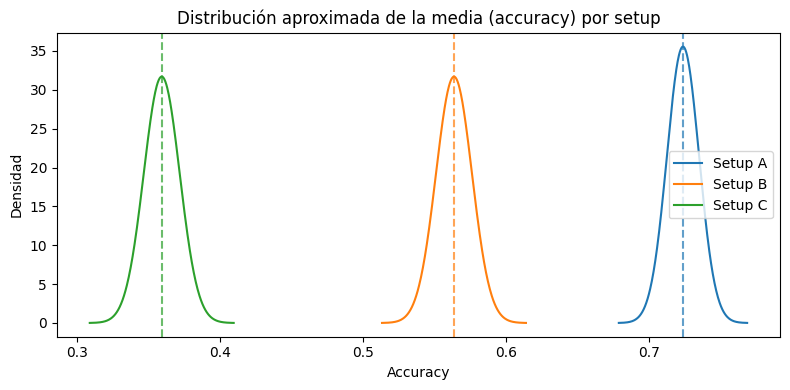

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = xgboost_results_levels[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

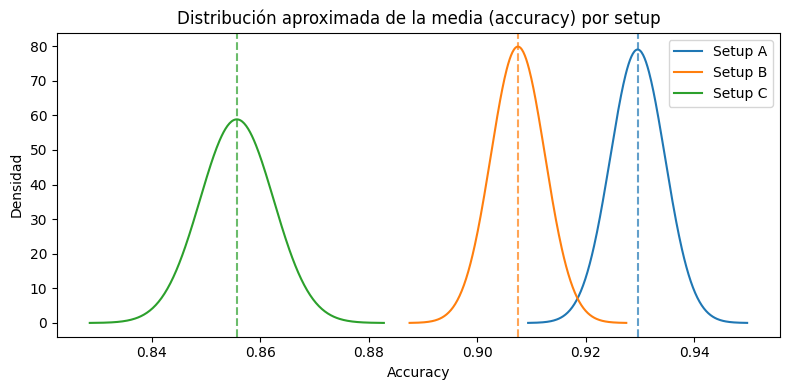

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = {'A': 'tab:blue', 'B': 'tab:orange', 'C': 'tab:green'}

for setup in ['A', 'B', 'C']:
    mean, low, high = xgboost_results_binary[setup]
    plot_normal_from_ci(mean, low, high, f'Setup {setup}', colors[setup], ax)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Densidad')
ax.set_title('Distribución aproximada de la media (accuracy) por setup')
ax.legend()
plt.tight_layout()
plt.show()

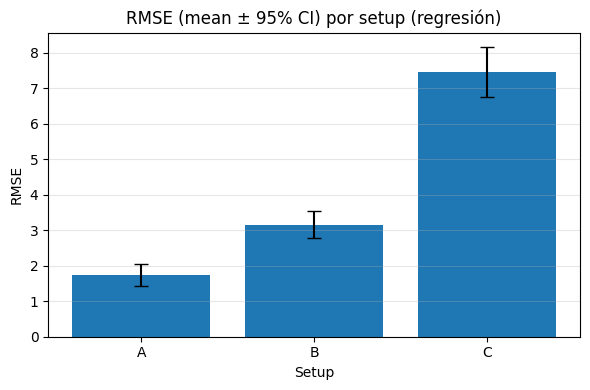

In [ ]:
df_reg = results_to_df(xgboost_results_direct, task_name="regression")

import matplotlib.pyplot as plt
import numpy as np

setups_order = ['A', 'B', 'C']

fig, ax = plt.subplots(figsize=(6, 4))

df_reg_plot = df_reg.set_index('setup').loc[setups_order]
means_rmse = df_reg_plot['mean'].values
errs_rmse = df_reg_plot['ci_err'].values

ax.bar(setups_order, means_rmse, yerr=errs_rmse, capsize=5)

ax.set_ylabel('RMSE')
ax.set_xlabel('Setup')
ax.set_title('RMSE (mean ± 95% CI) por setup (regresión)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones XG Boost

=== Levels classification, setup A ===
Accuracy: 0.7237 (95% CI: [0.7017, 0.7456])

=== Levels classification, setup B ===
Accuracy: 0.5634 (95% CI: [0.5388, 0.5881])

=== Levels classification, setup C ===
Accuracy: 0.3590 (95% CI: [0.3343, 0.3836])

=== Binary classification, setup A ===
Accuracy: 0.9296 (95% CI: [0.9197, 0.9395])

=== Binary classification, setup B ===
Accuracy: 0.9075 (95% CI: [0.8977, 0.9173])

=== Binary classification, setup C ===
Accuracy: 0.8557 (95% CI: [0.8424, 0.8690])

=== Regression, setup A ===
RMSE: 1.7471 (95% CI: [1.4385, 2.0558])

=== Regression, setup B ===
RMSE: 3.1549 (95% CI: [2.7703, 3.5395])

=== Regression, setup C ===
RMSE: 7.4553 (95% CI: [6.7587, 8.1518])

* las variables relacionadas con el desempeño académico previo de los estudiantes (G1 y G2) tienen un impacto muy importante en la capacidad predictiva del modelo XGBoost.

* El Setup A, que incluye todas las variables, fue el que obtuvo mejores resultados en las tres tareas evaluadas: clasificación multinivel, clasificación binaria y regresión.
Sin ellas, el rendimiento cae de forma drástica.

* En la clasificación multinivel, el modelo alcanzó 72.37% utilizando el Setup. Cuando se eliminó la variable G2 (Setup B), bajó a 56.34%, y al eliminar también G1 (Setup C), disminuyó hasta 35.90%. Esto indica que las calificaciones parciales contienen información muy importante para predecir el desempeño final del estudiante.

*En la clasificación binaria (aprueba o reprueba), el modelo obtuvo mejores resultados. El Setup A alcanzó una exactitud de 92.96%, mientras que los Setups B y C lograron 90.75% y 85.57%,

*el desempeño disminuye al eliminar G1 y G2 pero la caída no es tan fuerte como en la clasificación multinivel. Podemos concluir que las variables como ausencias, hábitos de estudio o apoyo familiar todavía aportan información útil para distinguir entre estudiantes aprobados y reprobados.


# Stacking


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

def make_linear_pipeline(feature_cols, df):

    preprocessor = make_generic_preprocessor(feature_cols)

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

    return model

for setup_name, feature_cols in setups.items():

    print("=" * 60)
    print(f"STACKING REGRESSION - SETUP {setup_name}")
    print("=" * 60)

    # Datos

    X = df[feature_cols]
    y = df['target']

    # Modelos a utilizar

    rf_model = make_rf_pipeline(
        feature_cols,
        df,
        task="regression"
    )

    dt_model = make_dt_pipeline(
        feature_cols,
        df,
        task="regression"
    )

    cat_model = make_catboost_pipeline(
        feature_cols
    )

    lin_model = make_linear_pipeline(
        feature_cols,
        df
    )

    # STACKING

    stack_model = StackingRegressor(

        estimators=[
            ('rf', rf_model),
            ('dt', dt_model),
            ('cat', cat_model),
            ('lr', lin_model)
        ],

        final_estimator=Ridge(),

        cv=5,

        n_jobs=-1
    )

    # Evaluacion

    stack_scores = repeated_cv_regression(
        X,
        y,
        stack_model,
        n_runs=3,
        n_splits=5
    )

    print(stack_scores)

    rmse_mean, rmse_low, rmse_high = mean_ci_95(stack_scores)

    print(f"RMSE Mean: {rmse_mean:.4f}")
    print(f"95% CI: [{rmse_low:.4f}, {rmse_high:.4f}]")
    print("\n")

Utilizando 4 modelos para realizar el stacking (random forest, decision tree, catboost, linear regression) se obtuvieron los valores de RMSE para cada setup.
Observando estos resultados tenemos que el setup A, que utiliza todos los datos, obtiene el mejor resultado con 1.6442, mientras que el setup B y C obtienen 3.1675 y 7.2073 respectivamente. Estos resultados van acorde a lo obtenido en otros modelos. El setup B y C al perder G1 Y G2 obtienen los peores resultados lo cual nos indica que el desempeño academico historico tiene gran relevancia al predecir el desempeño final de los estudiantes.

El stacking mostro resultados precisos despues de combinar varios modelos, especialmente al contar con todos los datos academicos historicos.

## Importancia de variables

In [ ]:
rf_df_vars

,setup,task,feature,importance
0,A,levels,school,0.011735
1,A,levels,sex,0.013165
2,A,levels,age,0.008956
3,A,levels,address,0.009012
4,A,levels,famsize,0.008142
...,...,...,...,...
265,C,regresion,goout,0.007066
266,C,regresion,Dalc,0.003027
267,C,regresion,Walc,0.009346
268,C,regresion,health,0.009845


In [ ]:
dt_df_vars

,setup,task,feature,importance
0,A,levels,school,0.030212
1,A,levels,sex,0.000000
2,A,levels,age,0.000000
3,A,levels,address,0.002249
4,A,levels,famsize,0.019332
...,...,...,...,...
265,C,regresion,goout,0.000000
266,C,regresion,Dalc,0.000000
267,C,regresion,Walc,0.000000
268,C,regresion,health,0.000000


In [ ]:
xgboost_df_vars

,setup,task,feature,importance
0,A,levels,school,0.016666
1,A,levels,sex,0.018112
2,A,levels,age,0.014321
3,A,levels,address,0.015563
4,A,levels,famsize,0.014583
...,...,...,...,...
265,C,regresion,goout,0.012926
266,C,regresion,Dalc,0.023571
267,C,regresion,Walc,0.017378
268,C,regresion,health,0.050320


In [ ]:
catboost_df_vars

,setup,task,feature,importance,model
0,A,regresion,school,2.050875,Catboost
1,A,regresion,sex,0.713793,Catboost
2,A,regresion,age,1.355401,Catboost
3,A,regresion,address,0.791533,Catboost
4,A,regresion,famsize,0.552834,Catboost
...,...,...,...,...,...
85,C,regresion,goout,1.340536,Catboost
86,C,regresion,Dalc,0.725714,Catboost
87,C,regresion,Walc,0.504480,Catboost
88,C,regresion,health,0.258915,Catboost


In [ ]:
lr_df_vars

,setup,task,feature,importance
0,A,regresion,school,0.059204
1,A,regresion,sex,-0.074678
2,A,regresion,age,0.050066
3,A,regresion,address,0.149306
4,A,regresion,famsize,0.052030
...,...,...,...,...
85,C,regresion,goout,-0.269708
86,C,regresion,Dalc,-0.007247
87,C,regresion,Walc,0.204103
88,C,regresion,health,0.055970


In [ ]:
lg_df_vars

,setup,task,feature,importance
0,A,levels,school,1.063769
1,A,levels,sex,0.266005
2,A,levels,age,0.349598
3,A,levels,address,0.378925
4,A,levels,famsize,0.344874
...,...,...,...,...
175,C,binary,goout,0.139704
176,C,binary,Dalc,0.033360
177,C,binary,Walc,0.497141
178,C,binary,health,1.021578


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Asignar nombre a cada modelo
rf_df_vars['model'] = 'Random Forest'
dt_df_vars['model'] = 'Decision Tree'
xgboost_df_vars['model'] = 'XGBoost'
lr_df_vars['model'] = 'Linear Regression'
lg_df_vars['model'] = 'Logistic Regression'
catboost_df_vars['model'] = 'Catboost'

# Unir todos los resultados
df_importance_all = pd.concat([rf_df_vars, dt_df_vars, xgboost_df_vars, lr_df_vars, lg_df_vars, catboost_df_vars], ignore_index=True)

# Normalizar
df_importance_all['importance_norm'] = df_importance_all.groupby(['model', 'task', 'setup'])['importance'].transform(
    lambda x: x / x.max() if x.max() != 0 else 0
)

# Filtrar solo las N más importantes para que el gráfico no sea muy grande
top_n = 5

# Sacamos el promedio de importancia por variable para elegir las mejores
top_features = df_importance_all.groupby('feature')['importance_norm'].mean().sort_values(ascending=False).head(top_n).index

df_importance_filtered_all = df_importance_all[df_importance_all['feature'].isin(top_features)]
df_importance_filtered_all

,setup,task,feature,importance,model,importance_norm
0,A,levels,school,0.011735,Random Forest,0.891371
1,A,levels,sex,0.013165,Random Forest,1.000000
12,A,levels,traveltime,0.009946,Random Forest,0.755453
13,A,levels,studytime,0.007571,Random Forest,0.575075
14,A,levels,failures,0.005863,Random Forest,0.445338
...,...,...,...,...,...,...
1140,C,regresion,school,4.033531,Catboost,0.356656
1141,C,regresion,sex,4.121575,Catboost,0.364441
1152,C,regresion,traveltime,6.289433,Catboost,0.556129
1153,C,regresion,studytime,2.799331,Catboost,0.247525


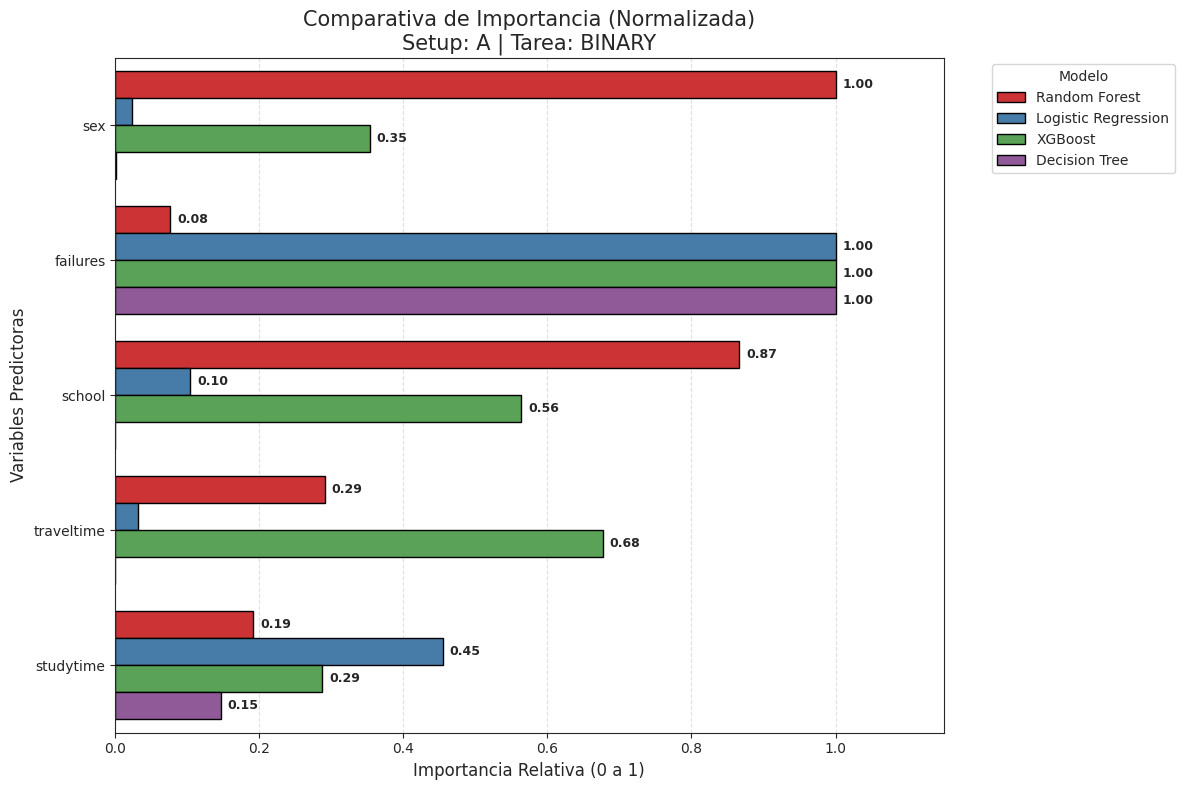

In [ ]:
def plot_feature_comparison(df, setup_label='A', task_label='binary'):
    # Filtrar por la combinación específica para el paper
    data_to_plot = df[(df['setup'] == setup_label) & (df['task'] == task_label)]

    plt.figure(figsize=(12, 8))
    sns.set_style("ticks")

    # Paleta Set1 para máximo contraste entre modelos
    ax = sns.barplot(
        data=data_to_plot.sort_values('importance_norm', ascending=False),
        x='importance_norm',
        y='feature',
        hue='model',
        palette='Set1',
        edgecolor='black',
        linewidth=1
    )

    # Añadir etiquetas de valor para precisión
    for p in ax.patches:
        width = p.get_width()
        if width > 0.05: # Solo anotar si hay espacio suficiente
            ax.annotate(f'{width:.2f}',
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center',
                        xytext=(5, 0),
                        textcoords='offset points',
                        fontsize=9, fontweight='bold')

    plt.title(f'Comparativa de Importancia (Normalizada)\nSetup: {setup_label} | Tarea: {task_label.upper()}', fontsize=15)
    plt.xlabel('Importancia Relativa (0 a 1)', fontsize=12)
    plt.ylabel('Variables Predictoras', fontsize=12)
    plt.xlim(0, 1.15) # Espacio para las etiquetas
    plt.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Ejecutar la comparativa principal
plot_feature_comparison(df_importance_filtered_all, setup_label='A', task_label='binary')

## Comparativa entre modelos

In [ ]:
rf_df_acc

,setup,task,mean,ci_low,ci_high,ci_err
0,A,binary,0.923967,0.916889,0.931046,0.007079
1,B,binary,0.903419,0.894100,0.912738,0.009319
2,C,binary,0.848475,0.840251,0.856700,0.008225
3,A,levels,1.659969,1.347857,1.972081,0.312112
4,B,levels,3.147026,2.736863,3.557189,0.410163
5,C,levels,7.283048,6.577824,7.988273,0.705224
6,A,regresion,1.659969,1.347857,1.972081,0.312112
7,B,regresion,3.147026,2.736863,3.557189,0.410163
8,C,regresion,7.283048,6.577824,7.988273,0.705224


In [ ]:
dt_df_acc

,setup,task,mean,ci_low,ci_high,ci_err
0,A,binary,0.931159,0.921931,0.940387,0.009228
1,B,binary,0.878267,0.862187,0.894346,0.016080
2,C,binary,0.835138,0.822822,0.847454,0.012316
3,A,levels,0.712908,0.689946,0.735870,0.022962
4,B,levels,0.561383,0.537219,0.585547,0.024164
5,C,levels,0.321527,0.303535,0.339518,0.017992
6,A,regresion,1.899216,1.611937,2.186496,0.287279
7,B,regresion,3.196906,2.815182,3.578629,0.381724
8,C,regresion,8.398508,7.550472,9.246544,0.848036


In [ ]:
catboost_results_df

,setup,setup,setup,RMSE mean,RMSE CI low,RMSE CI high,MAE mean,MAE CI low,MAE CI high,R2 mean,R2 CI low,R2 CI high
0,0,0,A,1.313224,1.179240,1.447208,0.837263,0.785508,0.889018,0.831450,0.811274,0.851626
1,1,1,B,1.745646,1.618201,1.873091,1.209155,1.162968,1.255343,0.701549,0.679112,0.723986
2,2,2,C,2.673036,2.519423,2.826649,1.958990,1.884410,2.033569,0.300189,0.267010,0.333369


In [ ]:
df_reporte_lineal

,Setup,RMSE mean,RMSE CI low,RMSE CI high,MAE mean,MAE CI low,MAE CI high,R2 mean,R2 CI low,R2 CI high,setup
0,A,1.292460,1.162508,1.422412,0.833164,0.779775,0.886554,0.835837,0.814706,0.856968,A
1,B,1.848350,1.675968,2.020731,1.249789,1.176370,1.323207,0.664498,0.624301,0.704695,B
2,C,2.760539,2.639237,2.881840,2.004097,1.937087,2.071106,0.249325,0.205750,0.292900,C


In [ ]:
df_acc_logreg

,setup,task,mean,ci_low,ci_high,ci_err
0,A,binary,0.928571,0.918719,0.938423,0.009852
1,B,binary,0.896235,0.884474,0.907996,0.011761
2,C,binary,0.848448,0.832567,0.864329,0.015881
3,A,levels,0.659495,0.638767,0.680224,0.020728
4,B,levels,0.532594,0.507956,0.557232,0.024638
5,C,levels,0.356883,0.329279,0.384488,0.027605


In [ ]:
xgboost_df_acc

,setup,task,mean,ci_low,ci_high,ci_err
0,A,binary,0.929600,0.919703,0.939498,0.009897
1,B,binary,0.907517,0.897725,0.917310,0.009793
2,C,binary,0.855659,0.842368,0.868950,0.013291
3,A,levels,0.723653,0.701661,0.745646,0.021993
4,B,levels,0.563447,0.538774,0.588119,0.024673
5,C,levels,0.358966,0.334299,0.383634,0.024668
6,A,regresion,1.747143,1.438512,2.055773,0.308630
7,B,regresion,3.154904,2.770310,3.539498,0.384594
8,C,regresion,7.455252,6.758739,8.151765,0.696513


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def transformar_resultado_regresion(df_reg, model_name):
    # Creamos la estructura compatible con df_all
    new_df = pd.DataFrame({
        'setup': df_reg['setup'],
        'task': 'regresion',
        'mean': df_reg['RMSE mean'],
        'ci_low': df_reg['RMSE CI low'],
        'ci_high': df_reg['RMSE CI high'],
        'model': model_name
    })

    # Calculamos ci_err para las barras de error
    new_df['ci_err'] = new_df['ci_high'] - new_df['mean']

    return new_df


# Transformamos los resultados de catboost y regresion lineal al schema del resto de dataframes
if 'setup' not in catboost_results_df.columns:
  catboost_results_df = catboost_results_df.reset_index().rename(columns={'index': 'setup'})
df_reporte_lineal['setup'] = df_reporte_lineal['Setup']

cb_df_acc = transformar_resultado_regresion(catboost_results_df, 'CatBoost')
lr_df_acc = transformar_resultado_regresion(df_reporte_lineal, 'Linear Regression')

# Agregamos columna model para identificar cada modelo
rf_df_acc['model'] = 'Random Forest'
dt_df_acc['model'] = 'Decision Tree'
df_acc_logreg['model'] = 'Logistic Regression'
xgboost_df_acc['model'] = 'XGBoost'


# Unir todos los resultados
df_all = pd.concat([rf_df_acc, dt_df_acc, df_acc_logreg, xgboost_df_acc, cb_df_acc, lr_df_acc], ignore_index=True)
df_all

,setup,task,mean,ci_low,ci_high,ci_err,model
0,A,binary,0.923967,0.916889,0.931046,0.007079,Random Forest
1,B,binary,0.903419,0.894100,0.912738,0.009319,Random Forest
2,C,binary,0.848475,0.840251,0.856700,0.008225,Random Forest
3,A,levels,0.729306,0.710222,0.748391,0.019084,Random Forest
4,B,levels,0.543948,0.522177,0.565718,0.021771,Random Forest
5,C,levels,0.354864,0.334742,0.374986,0.020122,Random Forest
6,A,regresion,1.659969,1.347857,1.972081,0.312112,Random Forest
7,B,regresion,3.147026,2.736863,3.557189,0.410163,Random Forest
8,C,regresion,7.283048,6.577824,7.988273,0.705224,Random Forest
9,A,binary,0.931159,0.921931,0.940387,0.009228,Decision Tree


In [ ]:
# Crear una tabla comparativa con pivote
pivot_table = df_all.pivot_table(
    index=['task', 'setup'],
    columns='model',
    values='mean'
)
pivot_table

model            CatBoost  Decision Tree  Linear Regression  \
task      setup                                               
binary    A           NaN       0.931159                NaN   
          B           NaN       0.878267                NaN   
          C           NaN       0.835138                NaN   
levels    A           NaN       0.712908                NaN   
          B           NaN       0.561383                NaN   
          C           NaN       0.321527                NaN   
regresion A      1.313224       1.899216           1.292460   
          B      1.745646       3.196906           1.848350   
          C      2.673036       8.398508           2.760539   

model            Logistic Regression  Random Forest   XGBoost  
task      setup                                                
binary    A                 0.928571       0.923967  0.929600  
          B                 0.896235       0.903419  0.907517  
          C                 0.848448       0.848475  0.855659  
levels    A                 0.659495       0.729306  0.723653  
          B                 0.532594       0.543948  0.563447  
          C                 0.356883       0.354864  0.358966  
regresion A                      NaN       1.659969  1.747143  
          B                      NaN       3.147026  3.154904  
          C                      NaN       7.283048  7.455252

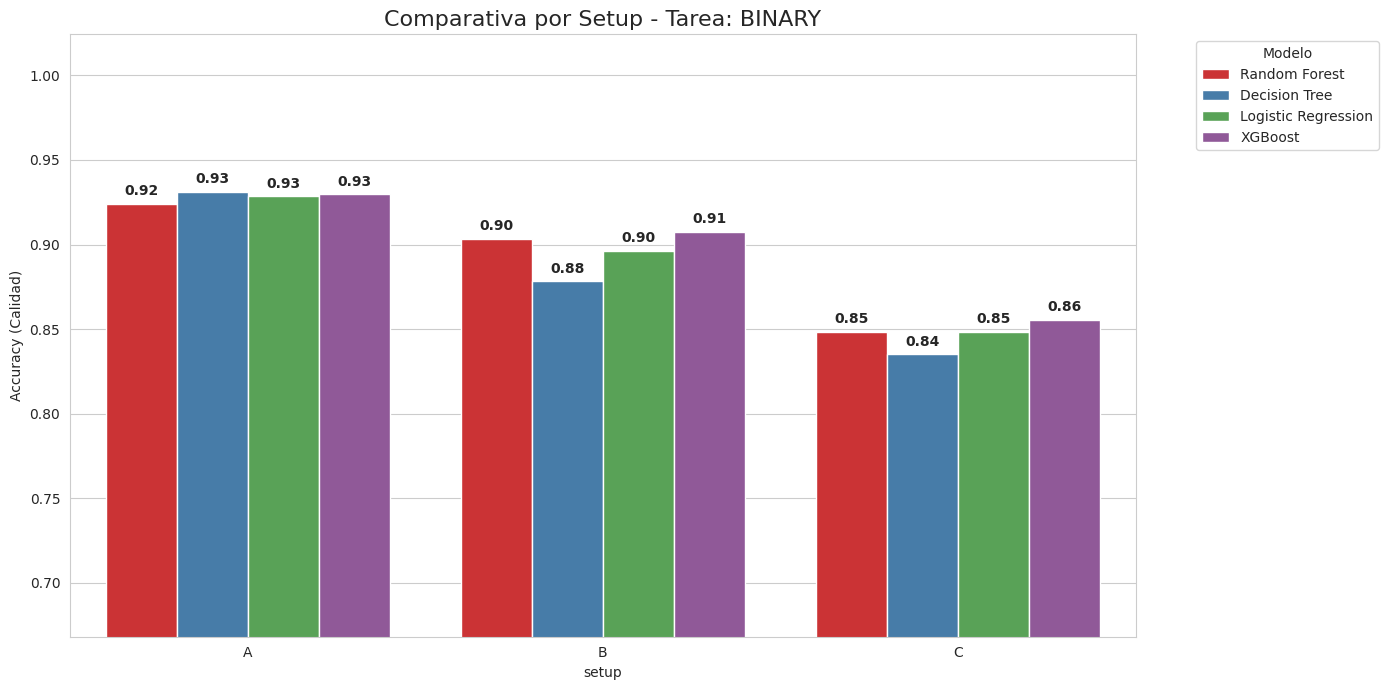

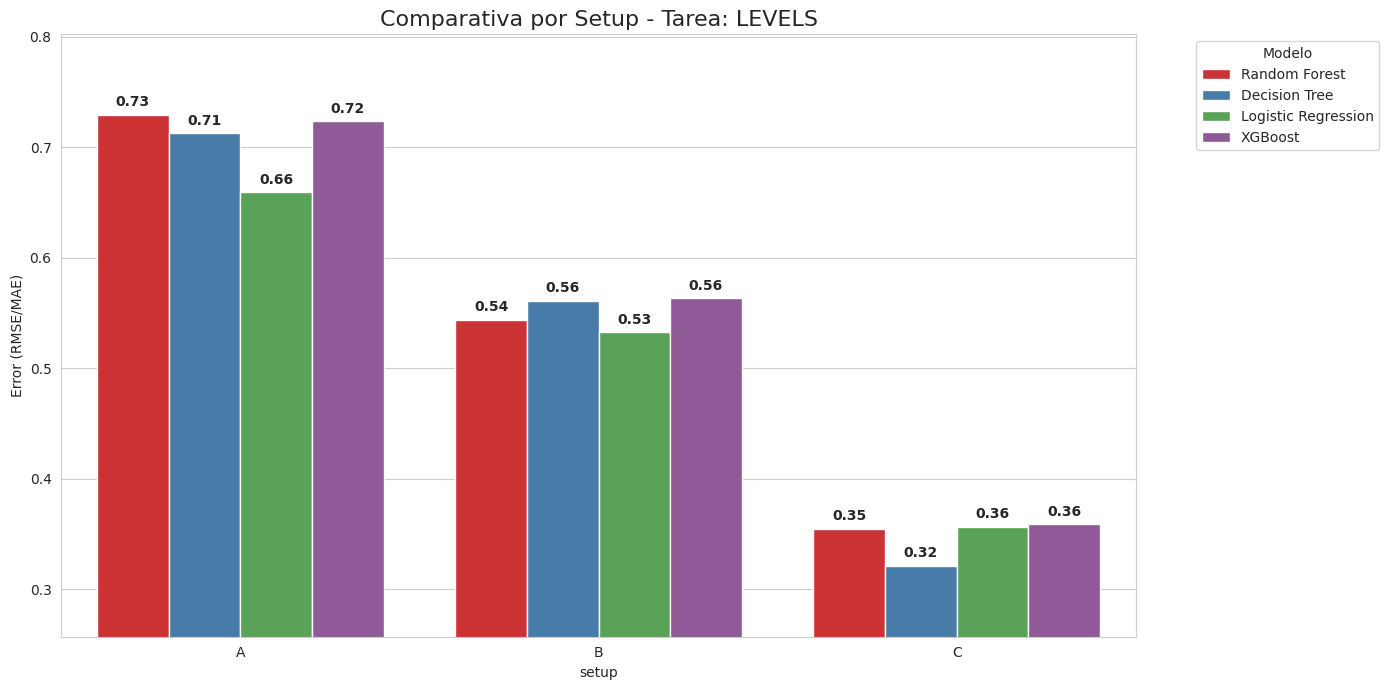

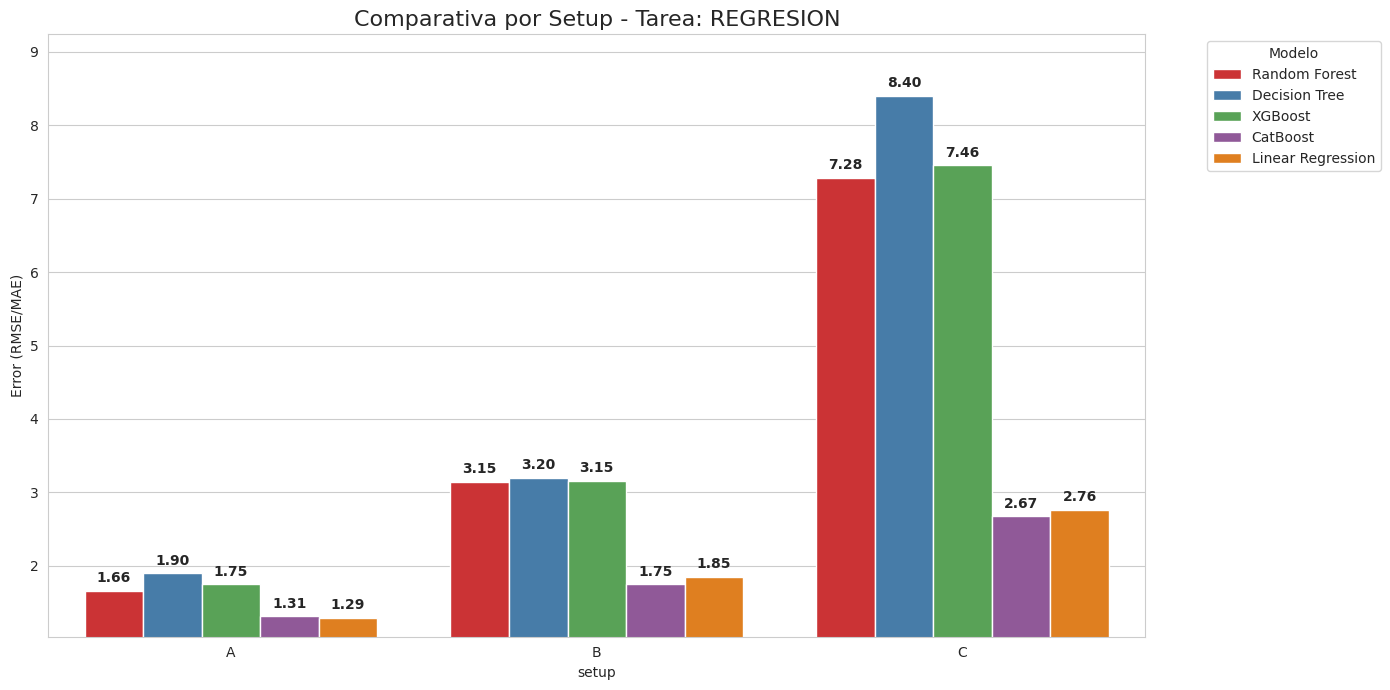

In [ ]:
def plot_comparativa_final(df, task_name, titulo_y):
    # Filtramos por el tipo de tarea
    subset = df[df['task'] == task_name].copy()

    if subset.empty:
        return

    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")

    # Graficamos
    ax = sns.barplot(
        data=subset,
        x='setup',
        y='mean',
        hue='model',
        palette='Set1',
        capsize=.1,
        err_kws={'linewidth': 1} # Aquí puedes usar ci_err si prefieres manual
    )

    # AGREGAR NÚMEROS SOBRE LAS BARRAS
    for p in ax.patches:
        if p.get_height() > 0: # Solo si la barra tiene altura
            ax.annotate(f'{p.get_height():.2f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=10, fontweight='bold')

    plt.title(f'Comparativa por Setup - Tarea: {task_name.upper()}', fontsize=16)
    plt.ylabel(titulo_y)
    plt.ylim(subset['mean'].min() * 0.8, subset['mean'].max() * 1.1) # Ajuste de escala para ver diferencias
    plt.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Ejecutamos para las tres tareas
plot_comparativa_final(df_all, 'binary', 'Accuracy (Calidad)')
plot_comparativa_final(df_all, 'levels', 'Error (RMSE/MAE)')
plot_comparativa_final(df_all, 'regresion', 'Error (RMSE/MAE)')

### Conclusiones de comparativa

### Clasificacion binaria
**Rendimiento por modelo (A > B > C)**
En los tres modelos clásicos (Random Forest, Decision Tree, Logistic Regression) y XGBoost, el rendimiento disminuye sistemáticamente de A → B → C.
Las medias para el setup A están alrededor de 0.92–0.93, mientras que en C bajan a ≈0.84–0.86 según el modelo.

**Comparativa entre modelos (para binaria)**

XGBoost y Random Forest son los que logran mejores resultados globales en casi todos los setups, con medias muy cercanas entre sí.
Logistic Regression también rinde bien, ligeramente por debajo de los métodos de árboles conjuntos.
Decision Tree simple es el que peor se comporta de los cuatro en binaria, aunque sigue manteniendo buenas métricas (>0.83 en C).

### Clasificacion multinivel (levels)
**Efecto del setup (A > B > C)**
Se observa una caída fuerte de rendimiento al pasar de A a C en todos los modelos.
Por ejemplo, en Random Forest:
A: ≈0.73
B: ≈0.54
C: ≈0.35

**Comparativa entre modelos (levels)**

Random Forest y XGBoost son los más competitivos para esta tarea, muy similares entre sí.
Decision Tree y Logistic Regression dan resultados peores en el setup C.
En general, la tarea de niveles es mucho más difícil que la binaria (todas las medias son notablemente más bajas).

### Modelos de regresión
CatBoost y Linear Regression son claramente superiores a los modelos de clasificación adaptados a regresión (Random Forest, XGBoost, Decision Tree), con errores mucho más bajos en todos los setups.

**Entre ambos:**
CatBoost y Linear Regression tienen rendimientos muy similares, con ligera ventaja de Linear Regression en A y C, y de CatBoost en B (diferencias pequeñas).

Ejemplo (error medio aproximado):

| Setup | Random Forest | XGBoost | Decision Tree | CatBoost | Linear Reg. |
|-------|---------------|---------|---------------|----------|-------------|
| A     | 1.66          | 1.75    | 1.90          | 1.31     | 1.29        |
| B     | 3.15          | 3.15    | 3.20          | 1.75     | 1.85        |
| C     | 7.28          | 7.46    | 8.40          | 2.67     | 2.76        |

**Efecto del setup en regresión**
Para los modelos de árboles (Random Forest, XGBoost, Decision Tree) el error crece de forma muy pronunciada al pasar de A → B → C (especialmente en C, donde el error se multiplica).
En CatBoost y Linear Regression, aunque también empeora el error de A a C, el crecimiento es mucho más moderado, lo que indica mayor robustez al cambio de setup.


* **Clasificación binaria:** XGBoost ≈ Random Forest > Logistic Regression > Decision Tree.
* **Clasificación multinivel:** XGBoost ≈ Random Forest > Logistic Regression ≈ Decision Tree, con caída fuerte de A a C.
* **Regresión:** CatBoost ≈ Linear Regression ≪ (mejor que) Random Forest ≈ XGBoost > Decision Tree, con mucha mayor robustez de CatBoost/Linear a cambios de setup.

El patrón general es A > B > C en calidad, con diferencias especialmente marcadas en la tarea de regresión para los modelos de árboles puros.
